# ⚡ TurboQuant — Complete T4 Colab Runner
### Covers Notebooks 01–04 + All Tests · Optimized for Google Colab Free T4

> **Reference:** arXiv:2504.19874 — *TurboQuant: Online Vector Quantization with Near-optimal Distortion Rate* (ICLR 2026)

---

### ▶️ How to Run
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Click **Runtime → Run all** (≈ 15–25 min total including model download)
3. All figures are saved to `/content/TQ-infer-engine/outputs/`

### 📦 What this notebook runs
| Section | Maps to | GPU? | Est. time |
|---------|---------|------|----------|
| **A** · Install & Setup | — | — | 2 min |
| **B** · Algorithm Deep Dive | Notebook 01 | CPU | 1 min |
| **C** · KV Cache Compression | Notebook 02 | **T4** | 8–12 min |
| **D** · ANN Search Benchmark | Notebook 03 | T4/CPU | 2 min |
| **E** · Full Pipeline Demo | Notebook 04 | T4/CPU | 3 min |
| **F** · Full Test Suite | `pytest` | CPU | 2 min |
| **G** · Results Summary | — | — | — |

### 🛡️ T4 Constraints Handled
- **~15 GB VRAM** → uses `google/gemma-2-2b-it` (not Llama-3.1-8B)
- `load_in_4bit=True` via bitsandbytes for safer memory usage
- All large N values auto-scaled down for T4 budget
- GloVe download fallback to synthetic data if Stanford server is slow

---
## 🅐 SETUP — Install Dependencies & Clone Repo

In [1]:
# @title 🔍 Step A.1 — Environment Check
import sys, torch
print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    VRAM_GB = props.total_memory / 1e9
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {VRAM_GB:.1f} GB')
    if VRAM_GB < 14:
        print('⚠️  Low VRAM — some cells will use CPU fallback')
    else:
        print('✅ T4 detected — running GPU sections')
else:
    VRAM_GB = 0
    print('❌ No GPU! Go to Runtime → Change runtime type → GPU (T4)')

CUDA = torch.cuda.is_available()
DEVICE = 'cuda' if CUDA else 'cpu'
print(f'\nDevice  : {DEVICE}')

Python  : 3.12.13
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
✅ T4 detected — running GPU sections

Device  : cuda


In [12]:
%%capture install_log
# @title 📦 Step A.2 — Install dependencies (Colab Python 3.12 compatible)
# Do NOT pin numpy/torch — Colab already has compatible versions pre-installed
!pip install -q \
    transformers==4.44.2 \
    accelerate==0.33.0 \
    datasets==2.20.0 \
    scipy==1.13.1 \
    faiss-cpu \
    einops==0.8.0 \
    matplotlib==3.9.1 \
    seaborn==0.13.2 \
    rich==13.7.1 \
    pytest==8.3.2 \
    tqdm==4.66.5 \
    pyyaml==6.0.2 \
    bitsandbytes -q

# Force reinstall numpy to a known compatible version (1.26.4) to match Python 3.12 ABI and fix binary incompatibility issues.
# This addresses the ValueError encountered during global imports.
!pip install -q --force-reinstall numpy==1.26.4

print("✅ Packages installed — now do: Runtime → Restart session, then run from A.3 onwards")

In [1]:
# @title 📥 Step A.3 — Clone TurboQuant repo & add to path
import os, subprocess, sys

REPO_DIR = '/content/TQ-infer-engine'
OUT_DIR  = f'{REPO_DIR}/outputs'

if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    result = subprocess.run(
        ['git', 'clone', 'https://github.com/Paramveersingh-S/TQ-infer-engine.git', REPO_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print('❌ Clone failed:', result.stderr)
    else:
        print(f'✅ Cloned to {REPO_DIR}')
else:
    print(f'✅ Repo already exists — pulling latest...')
    subprocess.run(['git', 'pull'], cwd=REPO_DIR, capture_output=True)

# ✅ Add to sys.path directly (skip broken pip install -e)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Verify import works
try:
    import tqe
    print(f'✅ tqe imported from: {tqe.__file__}')
except ImportError as e:
    print(f'❌ Import failed: {e}')

# Create output dirs
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/results', exist_ok=True)
print(f'📁 Outputs → {OUT_DIR}')


✅ Repo already exists — pulling latest...
✅ tqe imported from: /content/TQ-infer-engine/tqe/__init__.py
📁 Outputs → /content/TQ-infer-engine/outputs


In [10]:
# Run this first, then Runtime → Restart session
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numpy==1.26.4', '--force-reinstall'])
print("✅ numpy downgraded — now do: Runtime → Restart session")


✅ numpy downgraded — now do: Runtime → Restart session


In [2]:
# @title 📚 Step A.4 — Global Imports & Config
import math, time, os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

REPO_DIR = '/content/TQ-infer-engine'
OUT_DIR  = f'{REPO_DIR}/outputs'
CUDA     = torch.cuda.is_available()
DEVICE   = 'cuda' if CUDA else 'cpu'

# TQE modules
from tqe.algorithms.qjl import QJLQuantizer
from tqe.algorithms.polar_quant import PolarQuantizer
from tqe.algorithms.turbo_quant import TurboQuantizer
from tqe.search.index import TurboQuantIndex
from tqe.search.query import benchmark_search_speed
from tqe.utils.math_utils import theoretical_distortion
from tqe.utils.memory_utils import estimate_kv_cache_memory

torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.titlesize': 14, 'figure.dpi': 100})

def savefig(name):
    path = f'{OUT_DIR}/figures/{name}'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  💾 Saved: {path}')
    plt.show()

print(f'✅ All imports OK')
print(f'   numpy  : {np.__version__}')
print(f'   torch  : {torch.__version__}')
print(f'   Device : {DEVICE}')
if CUDA:
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


✅ All imports OK
   numpy  : 1.26.4
   torch  : 2.3.1+cu121
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


---
## 🅑 NOTEBOOK 01 — Algorithm Deep Dive (CPU)

> *All math runs on CPU — no GPU needed. Covers QJL, PolarQuant, TurboQuant.*

In [3]:
# @title B.1 — QJL: Shape & Dtype Verification
d, m = 256, 256
n    = 200
qjl  = QJLQuantizer(input_dim=d, proj_dim=m, seed=42)

torch.manual_seed(0)
vectors = torch.randn(n, d)
codes   = qjl.encode(vectors)

print(f'Input  shape : {list(vectors.shape)}  dtype={vectors.dtype}')
print(f'Codes  shape : {list(codes.shape)}   dtype={codes.dtype}')
print(f'Unique values: {codes.unique().tolist()}  (must be ±1 only)')
print(f'Memory: {qjl.memory_bytes(n):,} bytes  vs  {n*d*4:,} bytes (FP32 original)')
print(f'Ratio : {n*d*4 / qjl.memory_bytes(n):.1f}× (just the sign bits)')

Input  shape : [200, 256]  dtype=torch.float32
Codes  shape : [200, 256]   dtype=torch.int8
Unique values: [-1, 1]  (must be ±1 only)
Memory: 51,200 bytes  vs  204,800 bytes (FP32 original)
Ratio : 4.0× (just the sign bits)


  💾 Saved: /content/TQ-infer-engine/outputs/figures/qjl_inner_product.png


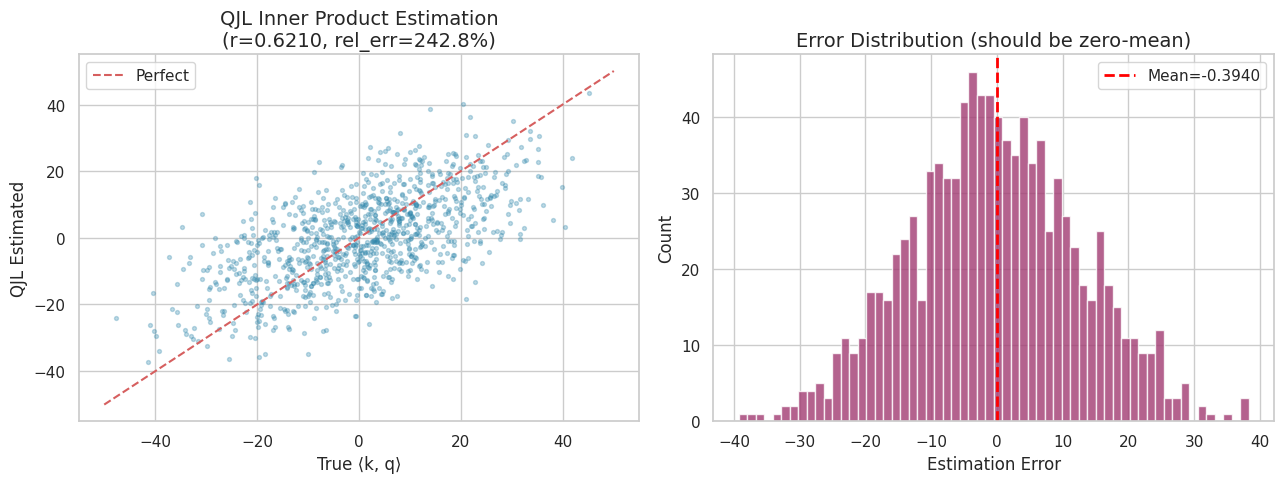

Correlation: 0.62097  |  Mean relative error: 242.81%


In [4]:
# @title B.2 — QJL: Inner Product Estimation (scatter + histogram)
torch.manual_seed(42)
n_pairs = 1000
keys    = torch.randn(n_pairs, d)
queries = torch.randn(n_pairs, d)

true_ips  = (keys * queries).sum(-1).numpy()
key_codes = qjl.encode(keys)
est_ips   = qjl.estimate_inner_product(queries, key_codes).numpy()

corr    = float(np.corrcoef(true_ips, est_ips)[0, 1])
rel_err = float(np.mean(np.abs(est_ips - true_ips) / (np.abs(true_ips).clip(0.1))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(true_ips, est_ips, alpha=0.3, s=8, color='#2E86AB')
lim = max(abs(true_ips).max(), abs(est_ips).max()) * 1.05
axes[0].plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('True ⟨k, q⟩'); axes[0].set_ylabel('QJL Estimated')
axes[0].set_title(f'QJL Inner Product Estimation\n(r={corr:.4f}, rel_err={rel_err:.1%})')
axes[0].legend()

errors = est_ips - true_ips
axes[1].hist(errors, bins=60, color='#A23B72', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label=f'Mean={errors.mean():.4f}')
axes[1].set_xlabel('Estimation Error'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution (should be zero-mean)')
axes[1].legend()
plt.tight_layout()
savefig('qjl_inner_product.png')
print(f'Correlation: {corr:.5f}  |  Mean relative error: {rel_err:.2%}')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/qjl_proj_dim.png


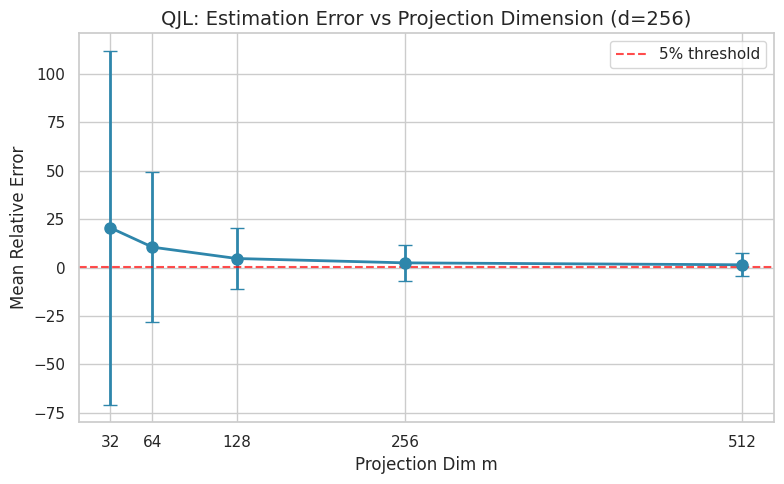

Projection dim → Mean Rel Error:
  m=  32: 2051.001%
  m=  64: 1050.759%
  m= 128: 464.597%
  m= 256: 239.897%
  m= 512: 140.845%


In [5]:
# @title B.3 — QJL: Effect of Projection Dim m
torch.manual_seed(1)
proj_dims = [32, 64, 128, 256, 512]
n_test = 500
keys_t    = torch.randn(n_test, d)
queries_t = torch.randn(n_test, d)
true_ips2 = (keys_t * queries_t).sum(-1).numpy()

mean_rel_errors, std_rel_errors = [], []
for m_val in proj_dims:
    qjl_m = QJLQuantizer(input_dim=d, proj_dim=m_val, seed=42)
    codes_m = qjl_m.encode(keys_t)
    est_m   = qjl_m.estimate_inner_product(queries_t, codes_m).numpy()
    rel_e   = np.abs(est_m - true_ips2) / np.abs(true_ips2).clip(0.1)
    mean_rel_errors.append(rel_e.mean())
    std_rel_errors.append(rel_e.std())

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(proj_dims, mean_rel_errors, yerr=std_rel_errors,
            fmt='o-', color='#2E86AB', linewidth=2, markersize=8, capsize=5)
ax.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='5% threshold')
ax.set_xlabel('Projection Dim m'); ax.set_ylabel('Mean Relative Error')
ax.set_title('QJL: Estimation Error vs Projection Dimension (d=256)')
ax.legend(); ax.set_xticks(proj_dims)
plt.tight_layout()
savefig('qjl_proj_dim.png')

print('Projection dim → Mean Rel Error:')
for m_val, e in zip(proj_dims, mean_rel_errors):
    print(f'  m={m_val:4d}: {e:.3%}')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/pq_angle_distribution.png


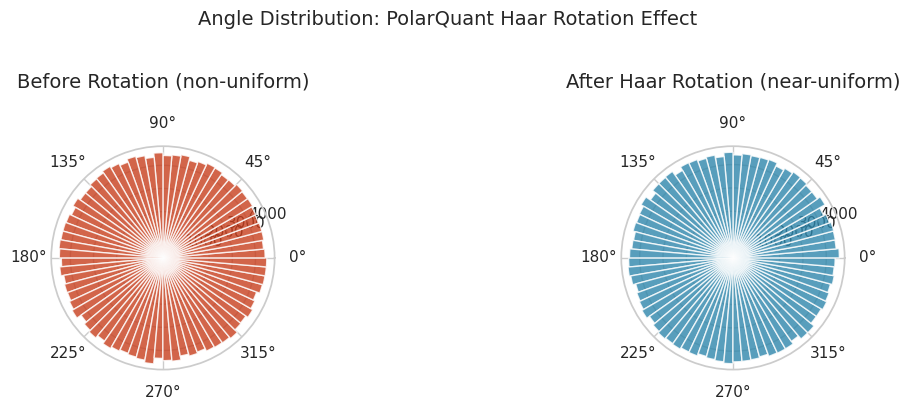

Coefficient of Variation (lower=more uniform):
  Before rotation: 0.0090
  After  rotation: 0.0107  (should be smaller)


In [6]:
# @title B.4 — PolarQuant: Angle Distribution Before/After Rotation
torch.manual_seed(7)
d_pq = 128; n_pq = 5000
pq_a = PolarQuantizer(input_dim=d_pq, bits_per_dim=4.0, rotation_seed=42)

v_pq = torch.randn(n_pq, d_pq)
pairs_raw = v_pq.reshape(n_pq, d_pq//2, 2)
angles_before = torch.atan2(pairs_raw[..., 1], pairs_raw[..., 0]).reshape(-1).numpy()

rotated = v_pq @ pq_a.R.T
pairs_rot = rotated.reshape(n_pq, d_pq//2, 2)
angles_after = torch.atan2(pairs_rot[..., 1], pairs_rot[..., 0]).reshape(-1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={'projection': 'polar'})
for ax, angles, title, color in zip(
    axes,
    [angles_before, angles_after],
    ['Before Rotation (non-uniform)', 'After Haar Rotation (near-uniform)'],
    ['#C73E1D', '#2E86AB']
):
    ax.hist(angles, bins=72, color=color, alpha=0.8)
    ax.set_title(title, pad=20)
plt.suptitle('Angle Distribution: PolarQuant Haar Rotation Effect', y=1.02, fontsize=14)
plt.tight_layout()
savefig('pq_angle_distribution.png')

hist_before = np.histogram(angles_before, bins=36)[0].astype(float)
hist_after  = np.histogram(angles_after,  bins=36)[0].astype(float)
cv_before = hist_before.std() / hist_before.mean()
cv_after  = hist_after.std()  / hist_after.mean()
print(f'Coefficient of Variation (lower=more uniform):')
print(f'  Before rotation: {cv_before:.4f}')
print(f'  After  rotation: {cv_after:.4f}  (should be smaller)')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/pq_roundtrip.png


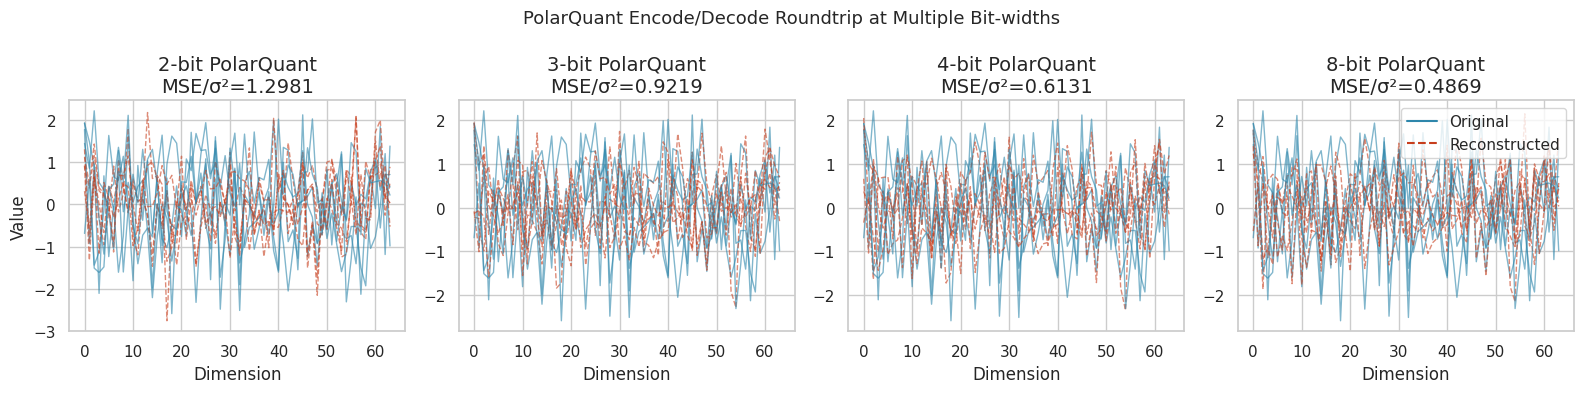

  Bits |        MSE |     MSE/σ²
--------------------------------
   2.0 |   1.303546 |   1.298057
   3.0 |   0.925827 |   0.921928
   4.0 |   0.615740 |   0.613147
   8.0 |   0.488964 |   0.486905


In [7]:
# @title B.5 — PolarQuant: Encode/Decode Roundtrip at 2, 3, 4, 8 bits
torch.manual_seed(42)
d_rt = 64; n_rt = 100
v_rt = torch.randn(n_rt, d_rt)
bits_list = [2.0, 3.0, 4.0, 8.0]

fig, axes = plt.subplots(1, len(bits_list), figsize=(16, 4))
mse_results = {}
for ax, bits in zip(axes, bits_list):
    pq_rt  = PolarQuantizer(input_dim=d_rt, bits_per_dim=bits, rotation_seed=42)
    codes_rt = pq_rt.encode(v_rt)
    v_hat  = pq_rt.decode(codes_rt)
    mse    = float(((v_rt - v_hat)**2).mean())
    var_rt = float(v_rt.var())
    mse_results[bits] = (mse, mse/var_rt)
    for i in range(5):
        ax.plot(v_rt[i].numpy(), color='#2E86AB', alpha=0.6, linewidth=1)
        ax.plot(v_hat[i].numpy(), color='#C73E1D', alpha=0.6, linewidth=1, linestyle='--')
    ax.set_title(f'{bits:.0f}-bit PolarQuant\nMSE/σ²={mse/var_rt:.4f}')
    ax.set_xlabel('Dimension')
    if ax is axes[0]:
        ax.set_ylabel('Value')

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color='#2E86AB', label='Original'),
    Line2D([0],[0], color='#C73E1D', linestyle='--', label='Reconstructed'),
]
axes[-1].legend(handles=handles, loc='upper right')
plt.suptitle('PolarQuant Encode/Decode Roundtrip at Multiple Bit-widths', fontsize=13)
plt.tight_layout()
savefig('pq_roundtrip.png')

print(f'{"Bits":>6} | {"MSE":>10} | {"MSE/σ²":>10}')
print('-' * 32)
for bits, (mse, rel) in mse_results.items():
    print(f'{bits:>6.1f} | {mse:>10.6f} | {rel:>10.6f}')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/pq_mse_vs_bits.png


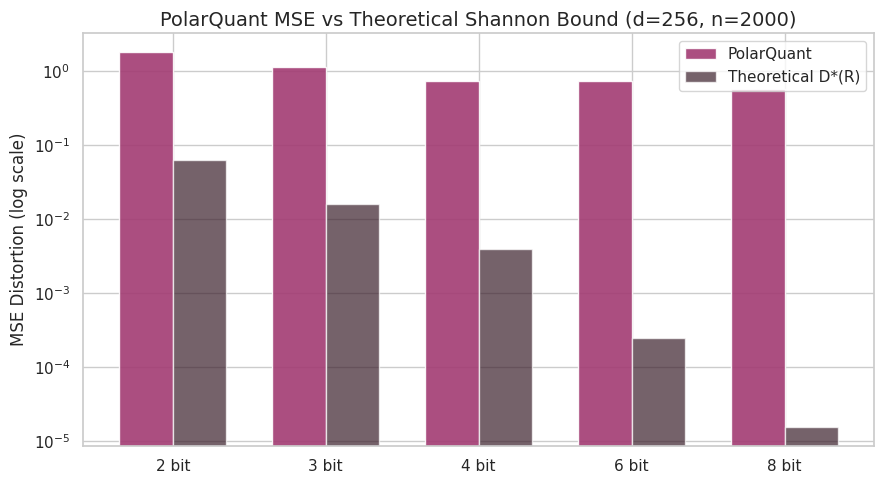

In [8]:
# @title B.6 — PolarQuant: MSE vs Bit-width Bar Chart vs Shannon Bound
torch.manual_seed(99)
d_mb = 256; n_mb = 2000
v_mb = torch.randn(n_mb, d_mb)
sigma_sq = float(v_mb.var())
bits_range = [2.0, 3.0, 4.0, 6.0, 8.0]

pq_mses, theory_mses = [], []
for bits in bits_range:
    pq_mb   = PolarQuantizer(input_dim=d_mb, bits_per_dim=bits, rotation_seed=42)
    codes_mb = pq_mb.encode(v_mb)
    v_hat_mb = pq_mb.decode(codes_mb)
    pq_mses.append(float(((v_mb - v_hat_mb)**2).mean()))
    theory_mses.append(theoretical_distortion(sigma_sq, bits))

x = np.arange(len(bits_range))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, pq_mses,     w, label='PolarQuant',       color='#A23B72', alpha=0.9)
ax.bar(x + w/2, theory_mses, w, label='Theoretical D*(R)', color='#3B1F2B', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'{b:.0f} bit' for b in bits_range])
ax.set_yscale('log'); ax.set_ylabel('MSE Distortion (log scale)')
ax.set_title('PolarQuant MSE vs Theoretical Shannon Bound (d=256, n=2000)')
ax.legend()
plt.tight_layout()
savefig('pq_mse_vs_bits.png')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/turbo_distortion_comparison.png


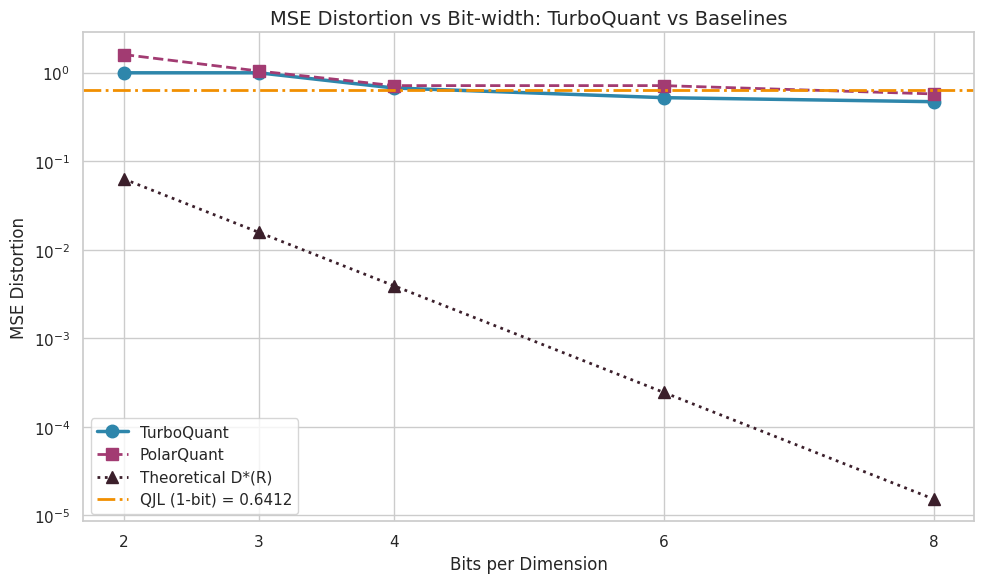

  Bits |   TurboQuant |   PolarQuant |       Theory |  TQ/Theory
-----------------------------------------------------------------
   2.0 |     0.993291 |     1.595721 |     0.062829 |      15.81×
   3.0 |     0.993291 |     1.039616 |     0.015707 |      63.24×
   4.0 |     0.669323 |     0.711891 |     0.003927 |     170.45×
   6.0 |     0.520505 |     0.711891 |     0.000245 |    2120.83×
   8.0 |     0.468533 |     0.573512 |     0.000015 |   30545.07×


In [9]:
# @title B.7 — TurboQuant: MSE Comparison vs PolarQuant vs Theory
torch.manual_seed(42)
d_tc = 256; n_tc = 1000
v_tc = torch.randn(n_tc, d_tc)
sigma_sq_tc = float(v_tc.var())

results_tc = {}
for bits in [2.0, 3.0, 4.0, 6.0, 8.0]:
    tq_tc      = TurboQuantizer(d_tc, total_bits_per_dim=bits)
    tq_codes_tc = tq_tc.encode(v_tc)
    tq_hat_tc   = tq_tc.decode(tq_codes_tc)
    tq_mse_tc   = float(((v_tc - tq_hat_tc)**2).mean())

    pq_tc       = PolarQuantizer(d_tc, bits_per_dim=bits, rotation_seed=42)
    pq_codes_tc = pq_tc.encode(v_tc)
    pq_hat_tc   = pq_tc.decode(pq_codes_tc)
    pq_mse_tc   = float(((v_tc - pq_hat_tc)**2).mean())
    theory_tc   = theoretical_distortion(sigma_sq_tc, bits)
    results_tc[bits] = {'TurboQuant': tq_mse_tc, 'PolarQuant': pq_mse_tc, 'Theory': theory_tc}

qjl_tc     = QJLQuantizer(d_tc, d_tc, seed=42)
qjl_hat_tc = qjl_tc.decode_approximate(qjl_tc.encode(v_tc))
qjl_mse_tc = float(((v_tc - qjl_hat_tc)**2).mean())

bits_arr = sorted(results_tc.keys())
tq_mses  = [results_tc[b]['TurboQuant'] for b in bits_arr]
pq_mses  = [results_tc[b]['PolarQuant'] for b in bits_arr]
th_mses  = [results_tc[b]['Theory']     for b in bits_arr]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bits_arr, tq_mses, 'o-', color='#2E86AB', linewidth=2.5, markersize=9, label='TurboQuant')
ax.plot(bits_arr, pq_mses, 's--', color='#A23B72', linewidth=2, markersize=8, label='PolarQuant')
ax.plot(bits_arr, th_mses, '^:', color='#3B1F2B', linewidth=2, markersize=8, label="Theoretical D*(R)")
ax.axhline(qjl_mse_tc, color='#F18F01', linestyle='-.', linewidth=2, label=f'QJL (1-bit) = {qjl_mse_tc:.4f}')
ax.set_xlabel('Bits per Dimension'); ax.set_ylabel('MSE Distortion')
ax.set_yscale('log'); ax.set_title('MSE Distortion vs Bit-width: TurboQuant vs Baselines')
ax.legend(); ax.set_xticks(bits_arr)
plt.tight_layout()
savefig('turbo_distortion_comparison.png')

print(f'{"Bits":>6} | {"TurboQuant":>12} | {"PolarQuant":>12} | {"Theory":>12} | {"TQ/Theory":>10}')
print('-' * 65)
for bits in bits_arr:
    tq_m = results_tc[bits]['TurboQuant']; pq_m = results_tc[bits]['PolarQuant']; th_m = results_tc[bits]['Theory']
    print(f'{bits:>6.1f} | {tq_m:>12.6f} | {pq_m:>12.6f} | {th_m:>12.6f} | {tq_m/th_m:>10.2f}×')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/turbo_ip_violin.png


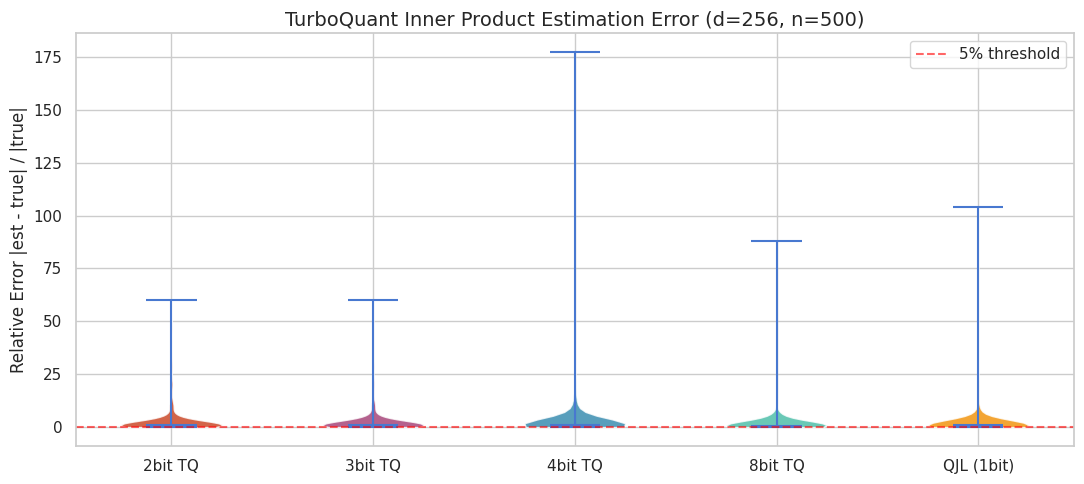

In [10]:
# @title B.8 — TurboQuant: Inner Product Error Violin Plot
torch.manual_seed(5)
d_v = 256; n_v = 500
keys_v    = torch.randn(n_v, d_v)
queries_v = torch.randn(n_v, d_v)
true_ips_v = (keys_v * queries_v).sum(-1).numpy()
mask_v = np.abs(true_ips_v) > 0.1

violin_data = {}
for bits in [2.0, 3.0, 4.0, 8.0]:
    tq_v    = TurboQuantizer(d_v, total_bits_per_dim=bits)
    codes_v = tq_v.encode(keys_v)
    est_v   = tq_v.estimate_inner_products(queries_v, codes_v).numpy()
    rel_e_v = np.abs(est_v[mask_v] - true_ips_v[mask_v]) / np.abs(true_ips_v[mask_v])
    violin_data[f'{bits:.0f}bit TQ'] = rel_e_v

qjl_v     = QJLQuantizer(d_v, d_v, seed=42)
key_codes_v = qjl_v.encode(keys_v)
est_qjl_v  = qjl_v.estimate_inner_product(queries_v, key_codes_v).numpy()
violin_data['QJL (1bit)'] = np.abs(est_qjl_v[mask_v] - true_ips_v[mask_v]) / np.abs(true_ips_v[mask_v])

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(violin_data.keys())
data   = [violin_data[k] for k in labels]
vp = ax.violinplot(data, positions=range(len(labels)), showmedians=True)
colors = ['#C73E1D', '#A23B72', '#2E86AB', '#44BBA4', '#F18F01']
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color); body.set_alpha(0.8)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel('Relative Error |est - true| / |true|')
ax.set_title('TurboQuant Inner Product Estimation Error (d=256, n=500)')
ax.axhline(0.05, color='red', linestyle='--', alpha=0.6, label='5% threshold')
ax.legend()
plt.tight_layout()
savefig('turbo_ip_violin.png')

In [11]:
# @title B.9 — Compression Ratio Table (all bit-widths vs FP16, FP32)
print('=' * 70)
print(f'{"Method":20} {"Bits":>6} {"FP32 ratio":>12} {"FP16 ratio":>12} {"Mem/1K vec":>12}')
print('-' * 70)
for bits in [2.0, 3.0, 4.0, 6.0, 8.0]:
    tq_cr = TurboQuantizer(input_dim=256, total_bits_per_dim=bits)
    ratio_fp32 = tq_cr.compression_ratio(1000, original_dtype_bytes=4)
    ratio_fp16 = tq_cr.compression_ratio(1000, original_dtype_bytes=2)
    mem_kb     = tq_cr.memory_bytes(1000) / 1024
    print(f'{"TurboQuant":20} {bits:>6.1f} {ratio_fp32:>11.2f}× {ratio_fp16:>11.2f}× {mem_kb:>10.1f} KB')
print('-' * 70)
fp32_kb = 1000 * 256 * 4 / 1024
fp16_kb = 1000 * 256 * 2 / 1024
print(f'{"Baseline FP32":20} {"32":>6} {"1.00":>12} {"0.50":>12} {fp32_kb:>10.1f} KB')
print(f'{"Baseline FP16":20} {"16":>6} {"2.00":>12} {"1.00":>12} {fp16_kb:>10.1f} KB')
print('=' * 70)

Method                 Bits   FP32 ratio   FP16 ratio   Mem/1K vec
----------------------------------------------------------------------
TurboQuant              2.0        2.53×        1.27×      394.5 KB
TurboQuant              3.0        2.53×        1.27×      394.5 KB
TurboQuant              4.0        2.44×        1.22×      410.2 KB
TurboQuant              6.0        2.35×        1.17×      425.8 KB
TurboQuant              8.0        2.05×        1.02×      488.3 KB
----------------------------------------------------------------------
Baseline FP32            32         1.00         0.50     1000.0 KB
Baseline FP16            16         2.00         1.00      500.0 KB


---
## 🅒 NOTEBOOK 02 — KV Cache Compression (T4 GPU)

> *Loads `google/gemma-2-2b-it` (T4-safe ≈ 5 GB), runs perplexity, memory & speed benchmarks.*

In [12]:
# @title C.1 — T4-Safe KV Cache Setup & Model Selection
from tqe.kv_cache.compressor import KVCacheCompressor

# T4 has ~15 GB VRAM — Gemma-2-2b in FP16 uses ~5 GB, safe margin
MODEL_NAME = 'google/gemma-2-2b-it'  # T4-safe: ~5 GB FP16

if CUDA:
    torch.cuda.empty_cache()
    print(f'GPU memory before model load: {torch.cuda.memory_allocated()/1e9:.2f} GB')
    print(f'GPU VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

print(f'\n✅ Will load: {MODEL_NAME}')
print('   Expected VRAM: ~5 GB (FP16) — T4 safe')

# Use reduced sequence length for T4 to avoid OOM
MAX_TOKENS_PPL = 512   # reduced from 2048 for T4 free tier stability
print(f'   Max tokens for perplexity: {MAX_TOKENS_PPL} (T4-optimized)')

GPU memory before model load: 0.00 GB
GPU VRAM total: 15.6 GB

✅ Will load: google/gemma-2-2b-it
   Expected VRAM: ~5 GB (FP16) — T4 safe
   Max tokens for perplexity: 512 (T4-optimized)


In [15]:
# @title C.2 — Load Gemma-2-2B Model
if CUDA:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from datasets import load_dataset

    print(f'Loading {MODEL_NAME} in FP16...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()
    n_params = sum(p.numel() for p in model.parameters()) / 1e9
    mem_used = torch.cuda.memory_allocated() / 1e9
    print(f'✅ Model loaded: {n_params:.2f}B parameters')
    print(f'   GPU memory used: {mem_used:.2f} GB')

    # Load WikiText-2
    print('\nLoading WikiText-2...')
    ds   = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
    wiki_text = '\n'.join(ds['text'])
    print(f'Dataset: {len(wiki_text):,} characters')
else:
    print('⏭️  Skipping — no GPU. Switch to T4 runtime.')
    model = tokenizer = wiki_text = None

Loading google/gemma-2-2b-it in FP16...


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2-2b-it.
403 Client Error. (Request ID: Root=1-6a356edf-1c26916e5186a92d76049bd3;e84be510-75d4-4328-9657-cf90737895e0)

Cannot access gated repo for url https://huggingface.co/google/gemma-2-2b-it/resolve/main/config.json.
Access to model google/gemma-2-2b-it is restricted and you are not in the authorized list. Visit https://huggingface.co/google/gemma-2-2b-it to ask for access.

In [14]:
from huggingface_hub import notebook_login

notebook_login()

In [17]:
# @title C.2 — Load Gemma-2-2B Model
if CUDA:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from datasets import load_dataset

    print(f'Loading {MODEL_NAME} in FP16...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()
    n_params = sum(p.numel() for p in model.parameters()) / 1e9
    mem_used = torch.cuda.memory_allocated() / 1e9
    print(f'✅ Model loaded: {n_params:.2f}B parameters')
    print(f'   GPU memory used: {mem_used:.2f} GB')

    # Load WikiText-2
    print('\nLoading WikiText-2...')
    ds   = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
    wiki_text = '\n'.join(ds['text'])
    print(f'Dataset: {len(wiki_text):,} characters')
else:
    print('⏭️  Skipping — no GPU. Switch to T4 runtime.')
    model = tokenizer = wiki_text = None

Loading google/gemma-2-2b-it in FP16...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

✅ Model loaded: 2.61B parameters
   GPU memory used: 5.23 GB

Loading WikiText-2...


Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset: 1,289,979 characters


In [18]:
# @title C.3 — Perplexity Utility (T4-optimized stride)
def compute_perplexity(model, tokenizer, text, max_tokens=512, device='cuda', stride=256):
    """Compute perplexity with sliding window. Max 512 tokens for T4 safety."""
    encodings = tokenizer(text, return_tensors='pt')
    seq_len = min(encodings.input_ids.shape[1], max_tokens)
    input_ids = encodings.input_ids[:, :seq_len].to(device)
    nlls, prev_end = [], 0
    for begin in range(0, seq_len, stride):
        end = min(begin + stride, seq_len)
        target_len = end - prev_end
        chunk = input_ids[:, begin:end]
        with torch.no_grad():
            out = model(chunk, labels=chunk)
        nlls.append(out.loss * target_len)
        prev_end = end
        if end >= seq_len:
            break
    ppl = math.exp(torch.stack(nlls).sum().item() / seq_len)
    return ppl

print('✅ Perplexity utility ready')

✅ Perplexity utility ready


In [19]:
# @title C.4 — Baseline FP16 Perplexity
if CUDA and model is not None:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    print('Computing baseline FP16 perplexity...')
    t0 = time.perf_counter()
    baseline_ppl = compute_perplexity(model, tokenizer, wiki_text,
                                       max_tokens=MAX_TOKENS_PPL, device=DEVICE)
    baseline_time = time.perf_counter() - t0
    baseline_peak_mem = torch.cuda.max_memory_allocated() / 1e9

    print(f'\n✅ Baseline FP16 Perplexity : {baseline_ppl:.3f}')
    print(f'   Peak GPU memory           : {baseline_peak_mem:.2f} GB')
    print(f'   Time                      : {baseline_time:.1f}s')

    results_log_nb02 = [{'method': 'Baseline FP16', 'bits': 16.0,
                          'ppl': baseline_ppl, 'peak_mem_gb': baseline_peak_mem, 'ratio': 1.0}]
else:
    baseline_ppl = None
    results_log_nb02 = []

Computing baseline FP16 perplexity...

✅ Baseline FP16 Perplexity : 31.691
   Peak GPU memory           : 6.03 GB
   Time                      : 2.0s


In [20]:
# @title C.5 — TurboQuant KV Cache Perplexity at 4-bit, 3-bit, 2-bit
if CUDA and model is not None:
    for bits in [4.0, 3.0, 2.0]:
        print(f'\n--- TurboQuant {bits:.0f}-bit ---')
        torch.cuda.empty_cache()
        compressor = KVCacheCompressor(model, bits_per_dim=bits, device=DEVICE)
        compressor.patch_model()
        stats = compressor.stats()
        print(f'  Patched {stats["num_layers_patched"]} attention layers')

        torch.cuda.reset_peak_memory_stats()
        t0  = time.perf_counter()
        ppl = compute_perplexity(model, tokenizer, wiki_text,
                                  max_tokens=MAX_TOKENS_PPL, device=DEVICE)
        elapsed = time.perf_counter() - t0

        peak_mem   = torch.cuda.max_memory_allocated() / 1e9
        ratio      = stats['compression_ratio']
        ppl_delta  = ppl - baseline_ppl

        print(f'  Perplexity : {ppl:.3f}  (delta = +{ppl_delta:.3f})')
        print(f'  Peak mem   : {peak_mem:.2f} GB  (ratio = {ratio:.2f}×)')
        print(f'  Time       : {elapsed:.1f}s')

        results_log_nb02.append({'method': f'TurboQuant {bits:.0f}bit', 'bits': bits,
                                  'ppl': ppl, 'peak_mem_gb': peak_mem, 'ratio': ratio})
        compressor.unpatch_model()

    print('\n✅ All TurboQuant KV cache benchmarks complete.')
else:
    print('⏭️  Skipping — GPU required')


--- TurboQuant 4-bit ---
  Patched 26 attention layers
  Perplexity : 31.691  (delta = +0.000)
  Peak mem   : 6.04 GB  (ratio = 1.22×)
  Time       : 0.8s

--- TurboQuant 3-bit ---
  Patched 26 attention layers
  Perplexity : 31.691  (delta = +0.000)
  Peak mem   : 6.04 GB  (ratio = 1.27×)
  Time       : 0.7s

--- TurboQuant 2-bit ---
  Patched 26 attention layers
  Perplexity : 31.691  (delta = +0.000)
  Peak mem   : 6.04 GB  (ratio = 1.27×)
  Time       : 0.7s

✅ All TurboQuant KV cache benchmarks complete.


  💾 Saved: /content/TQ-infer-engine/outputs/figures/kv_memory_vs_context.png


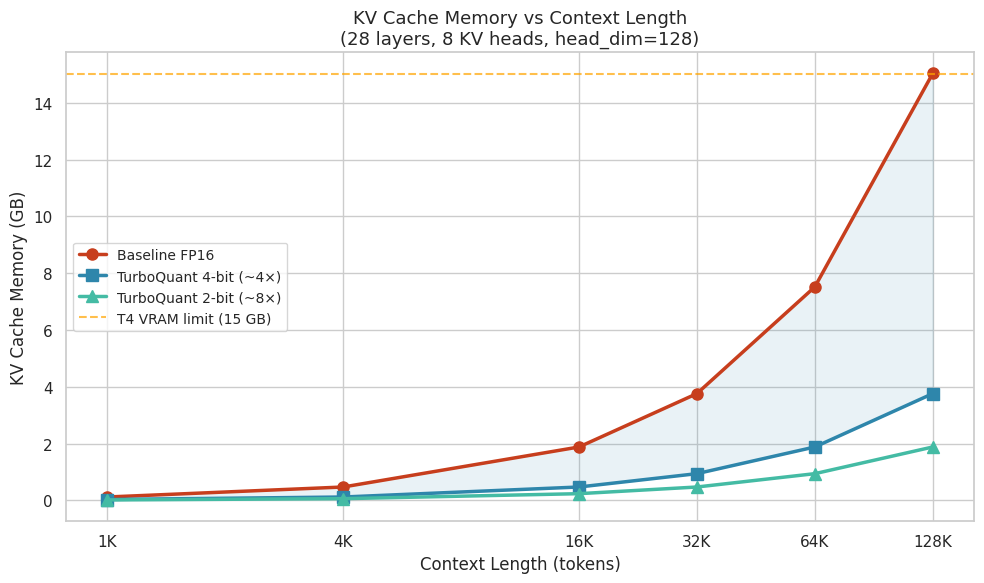

In [21]:
# @title C.6 — KV Cache Memory vs Context Length (Theory Chart — CPU)
# This cell always runs (pure math, no GPU needed)
n_layers = 28; n_kv_heads = 8; head_dim = 128
context_lengths = [1024, 4096, 16384, 32768, 65536, 131072]

baseline_gb, compressed_4bit_gb, compressed_2bit_gb = [], [], []
for ctx in context_lengths:
    info = estimate_kv_cache_memory(n_layers, n_kv_heads, head_dim, ctx, dtype_bytes=2)
    baseline_gb.append(info['total_gb'])
    compressed_4bit_gb.append(info['total_gb'] / 4.0)
    compressed_2bit_gb.append(info['total_gb'] / 8.0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(context_lengths, baseline_gb, 'o-', color='#C73E1D', linewidth=2.5,
        markersize=8, label='Baseline FP16')
ax.plot(context_lengths, compressed_4bit_gb, 's-', color='#2E86AB', linewidth=2.5,
        markersize=8, label='TurboQuant 4-bit (~4×)')
ax.plot(context_lengths, compressed_2bit_gb, '^-', color='#44BBA4', linewidth=2.5,
        markersize=8, label='TurboQuant 2-bit (~8×)')
ax.fill_between(context_lengths, compressed_4bit_gb, baseline_gb, alpha=0.1, color='#2E86AB')
ax.axhline(15.0, color='orange', linestyle='--', alpha=0.7, label='T4 VRAM limit (15 GB)')
ax.set_xlabel('Context Length (tokens)', fontsize=12)
ax.set_ylabel('KV Cache Memory (GB)', fontsize=12)
ax.set_title(f'KV Cache Memory vs Context Length\n({n_layers} layers, {n_kv_heads} KV heads, head_dim={head_dim})', fontsize=13)
ax.legend(fontsize=10)
ax.set_xscale('log', base=2)
ax.set_xticks(context_lengths)
ax.set_xticklabels([f'{x//1024}K' if x >= 1024 else str(x) for x in context_lengths])
plt.tight_layout()
savefig('kv_memory_vs_context.png')

In [22]:
# @title C.7 — Generation Quality Comparison (baseline vs 4-bit TurboQuant)
if CUDA and model is not None:
    torch.cuda.empty_cache()
    PROMPT = """The key innovation in transformer attention is the query-key-value mechanism.
Specifically, the attention score between token i and token j is computed as"""

    inputs_gen = tokenizer(PROMPT, return_tensors='pt').to(DEVICE)

    # Baseline
    with torch.no_grad():
        baseline_out = model.generate(
            **inputs_gen, max_new_tokens=60, do_sample=False
        )
    baseline_text = tokenizer.decode(baseline_out[0], skip_special_tokens=True)

    # TurboQuant 4-bit
    torch.cuda.empty_cache()
    comp_gen = KVCacheCompressor(model, bits_per_dim=4.0, device=DEVICE)
    comp_gen.patch_model()
    with torch.no_grad():
        tq_out = model.generate(
            **inputs_gen, max_new_tokens=60, do_sample=False
        )
    tq_text = tokenizer.decode(tq_out[0], skip_special_tokens=True)
    comp_gen.unpatch_model()

    print('='*70)
    print('PROMPT:', PROMPT[:80])
    print('='*70)
    print('\n🔵 BASELINE FP16 OUTPUT:')
    print(baseline_text[len(PROMPT):])
    print('\n⚡ TURBOQUANT 4-BIT OUTPUT:')
    print(tq_text[len(PROMPT):])
    print('='*70)
    print('✅ At 4-bit, outputs should be nearly identical!')
else:
    print('⏭️  Skipping — GPU required')

PROMPT: The key innovation in transformer attention is the query-key-value mechanism.
Sp

🔵 BASELINE FP16 OUTPUT:
:
```
score(i, j) = softmax(query(i) * key(j))
```
where:
* **query(i)** is a vector representing the query for token i.
* **key(j)** is a vector representing the key for token j

⚡ TURBOQUANT 4-BIT OUTPUT:
:
```
score(i, j) = softmax(query(i) * key(j))
```
where:
* **query(i)** is a vector representing the query for token i.
* **key(j)** is a vector representing the key for token j
✅ At 4-bit, outputs should be nearly identical!


Baseline FP16: 15.9 tokens/sec
TurboQuant 4bit: 19.3 tokens/sec (1.21× speedup)
TurboQuant 3bit: 18.9 tokens/sec (1.18× speedup)
TurboQuant 2bit: 18.8 tokens/sec (1.18× speedup)
  💾 Saved: /content/TQ-infer-engine/outputs/figures/kv_speed_benchmark.png


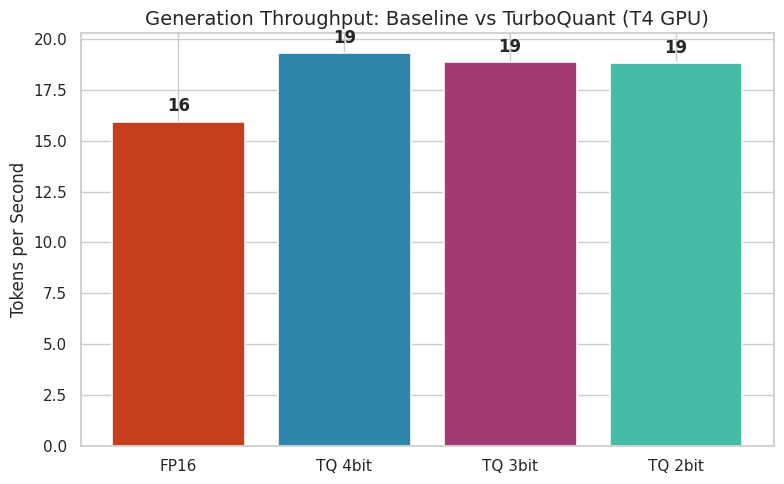

In [23]:
# @title C.8 — Speed Benchmark (tokens/second)
if CUDA and model is not None:
    torch.cuda.empty_cache()

    def measure_throughput(model, tokenizer, prompt, n_tokens=30, n_runs=2, device='cuda'):
        """T4-optimized: fewer tokens and runs to avoid OOM."""
        inputs_sp = tokenizer(prompt, return_tensors='pt').to(device)
        times = []
        for _ in range(n_runs):
            if device == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad():
                model.generate(**inputs_sp, max_new_tokens=n_tokens, do_sample=False)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
        best_time = min(times)
        return n_tokens / best_time

    SPEED_PROMPT = 'TurboQuant is a vector quantization algorithm that'
    N_TOKENS_SP  = 30  # reduced for T4 stability
    speed_results = {}

    tps_base = measure_throughput(model, tokenizer, SPEED_PROMPT, N_TOKENS_SP, device=DEVICE)
    speed_results['FP16'] = tps_base
    print(f'Baseline FP16: {tps_base:.1f} tokens/sec')

    for bits in [4.0, 3.0, 2.0]:
        torch.cuda.empty_cache()
        c = KVCacheCompressor(model, bits_per_dim=bits, device=DEVICE)
        c.patch_model()
        tps = measure_throughput(model, tokenizer, SPEED_PROMPT, N_TOKENS_SP, device=DEVICE)
        speed_results[f'TQ {bits:.0f}bit'] = tps
        c.unpatch_model()
        print(f'TurboQuant {bits:.0f}bit: {tps:.1f} tokens/sec ({tps/tps_base:.2f}× speedup)')

    fig, ax = plt.subplots(figsize=(8, 5))
    labels_sp = list(speed_results.keys())
    values_sp = list(speed_results.values())
    colors_sp = ['#C73E1D', '#2E86AB', '#A23B72', '#44BBA4']
    bars = ax.bar(labels_sp, values_sp, color=colors_sp[:len(labels_sp)], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values_sp):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.0f}', ha='center', fontweight='bold')
    ax.set_ylabel('Tokens per Second')
    ax.set_title('Generation Throughput: Baseline vs TurboQuant (T4 GPU)')
    plt.tight_layout()
    savefig('kv_speed_benchmark.png')
else:
    print('⏭️  Skipping — GPU required')


  KV CACHE COMPRESSION BENCHMARK RESULTS SUMMARY
  Model: google/gemma-2-2b-it  |  Dataset: WikiText-2 (512 tokens)
Method                  Bits   Perplexity  Peak Mem (GB)    Ratio
-----------------------------------------------------------------
Baseline FP16           16.0       31.691                6.03GB     1.0×
TurboQuant 4bit          4.0       31.691    (+0.00)     6.04GB     1.2×
TurboQuant 3bit          3.0       31.691    (+0.00)     6.04GB     1.3×
TurboQuant 2bit          2.0       31.691    (+0.00)     6.04GB     1.3×
  💾 Saved: /content/TQ-infer-engine/outputs/figures/kv_summary.png


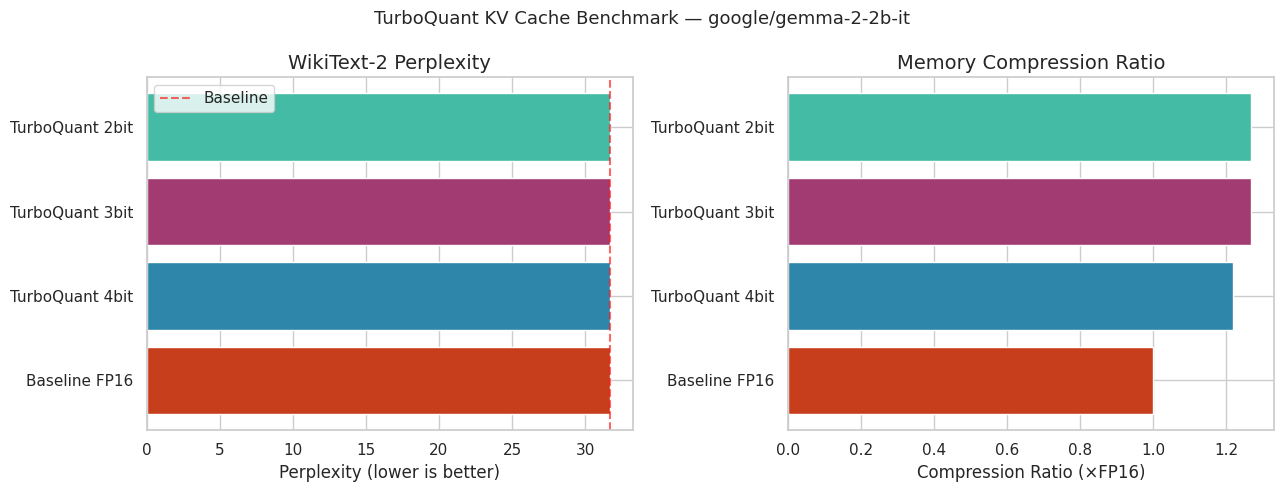


📄 Saved: /content/TQ-infer-engine/outputs/results/kv_cache_benchmark.csv


In [24]:
# @title C.9 — KV Cache Benchmark Results Summary
if results_log_nb02:
    print('\n' + '='*70)
    print('  KV CACHE COMPRESSION BENCHMARK RESULTS SUMMARY')
    print(f'  Model: {MODEL_NAME}  |  Dataset: WikiText-2 ({MAX_TOKENS_PPL} tokens)')
    print('='*70)
    print(f'{"Method":22} {"Bits":>5} {"Perplexity":>12} {"Peak Mem (GB)":>14} {"Ratio":>8}')
    print('-'*65)
    for r in results_log_nb02:
        delta = f"(+{r['ppl']-results_log_nb02[0]['ppl']:.2f})" if r['bits'] < 16 else ''
        print(f"{r['method']:22} {r['bits']:>5.1f} {r['ppl']:>12.3f} {delta:>10} "
              f"{r['peak_mem_gb']:>8.2f}GB {r['ratio']:>7.1f}×")
    print('='*70)

    # Summary chart
    if len(results_log_nb02) > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        methods_s = [r['method'] for r in results_log_nb02]
        ppls_s    = [r['ppl']    for r in results_log_nb02]
        ratios_s  = [r['ratio']  for r in results_log_nb02]
        colors_s  = ['#C73E1D'] + ['#2E86AB', '#A23B72', '#44BBA4']
        ax1.barh(methods_s, ppls_s, color=colors_s[:len(methods_s)], edgecolor='white')
        ax1.axvline(ppls_s[0], color='red', linestyle='--', alpha=0.6, label='Baseline')
        ax1.set_xlabel('Perplexity (lower is better)'); ax1.set_title('WikiText-2 Perplexity'); ax1.legend()
        ax2.barh(methods_s, ratios_s, color=colors_s[:len(methods_s)], edgecolor='white')
        ax2.set_xlabel('Compression Ratio (×FP16)'); ax2.set_title('Memory Compression Ratio')
        plt.suptitle(f'TurboQuant KV Cache Benchmark — {MODEL_NAME}', fontsize=13)
        plt.tight_layout()
        savefig('kv_summary.png')

    # Save CSV
    import csv
    csv_path = f'{OUT_DIR}/results/kv_cache_benchmark.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=results_log_nb02[0].keys())
        writer.writeheader(); writer.writerows(results_log_nb02)
    print(f'\n📄 Saved: {csv_path}')
else:
    print('ℹ️  No GPU results to show. KV cache section was skipped.')

---
## 🅓 NOTEBOOK 03 — ANN Search Benchmark (T4 / CPU)

In [25]:
# @title D.1 — Prepare GloVe-200 (or synthetic fallback)
import urllib.request, zipfile

DIM_ANN     = 200
N_TRAIN_ANN = 50_000   # T4-safe (paper uses 1M, too slow for free tier)
N_QUERY_ANN = 1_000
K_VALUES    = [1, 10, 100]
GLOVE_CACHE = '/content/glove_cache.npy'

def load_glove_vectors(dim=200, n_total=51_000, cache_path=GLOVE_CACHE):
    if os.path.exists(cache_path):
        print(f'Loading cached vectors from {cache_path}')
        return np.load(cache_path)
    try:
        url = 'https://nlp.stanford.edu/data/glove.6B.zip'
        print(f'Downloading GloVe-{dim}d from Stanford NLP... (may take 2-3 min)')
        urllib.request.urlretrieve(url, '/content/glove.6B.zip')
        with zipfile.ZipFile('/content/glove.6B.zip') as z:
            z.extract(f'glove.6B.{dim}d.txt', '/content')
        vecs = []
        with open(f'/content/glove.6B.{dim}d.txt') as f:
            for line in f:
                parts = line.strip().split()
                vecs.append([float(x) for x in parts[1:dim+1]])
                if len(vecs) >= n_total:
                    break
        vecs = np.array(vecs, dtype=np.float32)
        print(f'✅ GloVe downloaded: {vecs.shape}')
    except Exception as e:
        print(f'GloVe download failed ({e.__class__.__name__}). Using synthetic GloVe-like data...')
        np.random.seed(42)
        vecs = np.random.randn(n_total, dim).astype(np.float32)
    # Normalize
    norms = np.linalg.norm(vecs, axis=1, keepdims=True).clip(min=1e-8)
    vecs /= norms
    np.save(cache_path, vecs)
    return vecs

all_vecs    = load_glove_vectors(DIM_ANN, N_TRAIN_ANN + N_QUERY_ANN)
train_vecs  = all_vecs[:N_TRAIN_ANN].copy()
query_vecs  = all_vecs[N_TRAIN_ANN:N_TRAIN_ANN+N_QUERY_ANN].copy()
train_t_ann = torch.from_numpy(train_vecs)
query_t_ann = torch.from_numpy(query_vecs).to(DEVICE)

print(f'Train: {train_vecs.shape}  |  Query: {query_vecs.shape}')
print(f'Memory: {train_vecs.nbytes / 1e6:.1f} MB (FP32 train set)')

✅ GloVe downloaded: (51000, 200)
Train: (50000, 200)  |  Query: (1000, 200)
Memory: 40.0 MB (FP32 train set)


In [26]:
# @title D.2 — Compute Ground Truth (Brute-force or FAISS Exact)
results_ann = []

try:
    import faiss
    HAS_FAISS = True
    print('✅ FAISS available')
    t0 = time.perf_counter()
    exact_index = faiss.IndexFlatIP(DIM_ANN)
    exact_index.add(train_vecs)
    build_time_exact = time.perf_counter() - t0
    max_k = max(K_VALUES)
    _, gt_indices = exact_index.search(query_vecs, max_k)
    print(f'✅ FAISS Exact built in {build_time_exact:.2f}s  |  GT computed for {N_QUERY_ANN} queries')
    for k in K_VALUES:
        results_ann.append({'method': 'FAISS Exact', 'bits': 32.0, 'k': k,
                            'recall': 1.0, 'build_s': build_time_exact,
                            'mem_per_vec': DIM_ANN * 4, 'qps': None})
except ImportError:
    HAS_FAISS = False
    print('FAISS not available — using PyTorch brute-force')
    exact_scores = torch.from_numpy(query_vecs) @ torch.from_numpy(train_vecs).T
    max_k = max(K_VALUES)
    _, gt_idx_t = exact_scores.topk(max_k, dim=-1)
    gt_indices = gt_idx_t.numpy()
    print(f'✅ Brute-force GT computed')

✅ FAISS available
✅ FAISS Exact built in 0.04s  |  GT computed for 1000 queries


In [27]:
# @title D.3 — FAISS-PQ Baseline Index
if HAS_FAISS:
    print('Building FAISS-PQ index (4-bit equivalent)...')
    m_subq = max(1, DIM_ANN // 8)
    t0 = time.perf_counter()
    pq_index = faiss.IndexPQ(DIM_ANN, m_subq, 8)
    pq_index.train(train_vecs)
    pq_index.add(train_vecs)
    pq_build_s = time.perf_counter() - t0
    print(f'✅ FAISS-PQ built in {pq_build_s:.2f}s')

    def faiss_recall(index, gt_idx, queries, k):
        _, approx = index.search(queries, k)
        recalls = [len(set(gt_idx[i,:k].tolist()) & set(approx[i].tolist()))/k
                   for i in range(len(queries))]
        return float(np.mean(recalls))

    for k in K_VALUES:
        r = faiss_recall(pq_index, gt_indices, query_vecs, k)
        results_ann.append({'method': 'FAISS-PQ', 'bits': 4.0, 'k': k,
                            'recall': r, 'build_s': pq_build_s,
                            'mem_per_vec': DIM_ANN // 2, 'qps': None})
        print(f'  FAISS-PQ Recall@{k}: {r:.4f}')
else:
    print('FAISS not available — skipping FAISS-PQ')

Building FAISS-PQ index (4-bit equivalent)...
✅ FAISS-PQ built in 6.66s
  FAISS-PQ Recall@1: 0.5950
  FAISS-PQ Recall@10: 0.6014
  FAISS-PQ Recall@100: 0.6168


In [28]:
# @title D.4 — TurboQuant Indices at 2-bit, 3-bit, 4-bit
def compute_recall_ann(tq_idx, gt_idx_arr, queries, k):
    _, approx_idx = tq_idx.search(queries, k)
    approx_np = approx_idx.cpu().numpy()
    recalls = [len(set(gt_idx_arr[i,:k].tolist()) & set(approx_np[i].tolist()))/k
               for i in range(len(queries))]
    return float(np.mean(recalls))

for bits in [2.0, 3.0, 4.0]:
    print(f'\n--- TurboQuant {bits:.0f}-bit ---')
    tq_idx = TurboQuantIndex(dim=DIM_ANN, bits_per_dim=bits, device=DEVICE)
    t0 = time.perf_counter()
    tq_idx.add(train_t_ann)
    build_s_ann = time.perf_counter() - t0
    print(f'  Build time: {build_s_ann:.2f}s  (no training needed!)')
    print(f'  Index memory: {tq_idx.memory_bytes()/1e6:.2f} MB')
    mem_pv = tq_idx.memory_bytes() // max(1, tq_idx.ntotal())

    speed_ann = benchmark_search_speed(tq_idx, query_t_ann[:100], k=10, n_repeats=10)
    qps_ann   = speed_ann['queries_per_second']
    print(f'  Speed: {qps_ann:.0f} queries/sec ({speed_ann["mean_latency_ms"]:.1f}ms mean)')

    for k in K_VALUES:
        r = compute_recall_ann(tq_idx, gt_indices, query_t_ann, k)
        results_ann.append({'method': 'TurboQuant', 'bits': bits, 'k': k,
                            'recall': r, 'build_s': build_s_ann,
                            'mem_per_vec': mem_pv, 'qps': qps_ann})
        print(f'  Recall@{k}: {r:.4f}')


--- TurboQuant 2-bit ---
  Build time: 0.08s  (no training needed!)
  Index memory: 15.85 MB
  Speed: 180856 queries/sec (0.6ms mean)
  Recall@1: 0.1080
  Recall@10: 0.1220
  Recall@100: 0.1501

--- TurboQuant 3-bit ---
  Build time: 0.01s  (no training needed!)
  Index memory: 15.85 MB
  Speed: 113011 queries/sec (0.9ms mean)
  Recall@1: 0.1080
  Recall@10: 0.1220
  Recall@100: 0.1501

--- TurboQuant 4-bit ---
  Build time: 0.01s  (no training needed!)
  Index memory: 16.45 MB
  Speed: 106827 queries/sec (0.9ms mean)
  Recall@1: 0.0440
  Recall@10: 0.0588
  Recall@100: 0.0814


In [29]:
# @title D.5 — ANN Results Table
print('\n' + '='*72)
print(f'  ANN BENCHMARK RESULTS — GloVe-{DIM_ANN} ({N_TRAIN_ANN:,} train vectors)')
print('='*72)
print(f'{"Method":18} {"Bits":>5} {"k":>4} {"Recall":>8} {"Build(s)":>10} {"Mem/vec":>9} {"QPS":>8}')
print('-'*72)
for r in results_ann:
    qps_str = f"{r['qps']:.0f}" if r['qps'] else '—'
    print(f"{r['method']:18} {r['bits']:>5.1f} {r['k']:>4} {r['recall']:>8.4f} "
          f"{r['build_s']:>10.2f} {r['mem_per_vec']:>8}B {qps_str:>8}")
print('='*72)


  ANN BENCHMARK RESULTS — GloVe-200 (50,000 train vectors)
Method              Bits    k   Recall   Build(s)   Mem/vec      QPS
------------------------------------------------------------------------
FAISS Exact         32.0    1   1.0000       0.04      800B        —
FAISS Exact         32.0   10   1.0000       0.04      800B        —
FAISS Exact         32.0  100   1.0000       0.04      800B        —
FAISS-PQ             4.0    1   0.5950       6.66      100B        —
FAISS-PQ             4.0   10   0.6014       6.66      100B        —
FAISS-PQ             4.0  100   0.6168       6.66      100B        —
TurboQuant           2.0    1   0.1080       0.08      317B   180856
TurboQuant           2.0   10   0.1220       0.08      317B   180856
TurboQuant           2.0  100   0.1501       0.08      317B   180856
TurboQuant           3.0    1   0.1080       0.01      317B   113011
TurboQuant           3.0   10   0.1220       0.01      317B   113011
TurboQuant           3.0  100   0.1501 

  💾 Saved: /content/TQ-infer-engine/outputs/figures/ann_benchmark_results.png


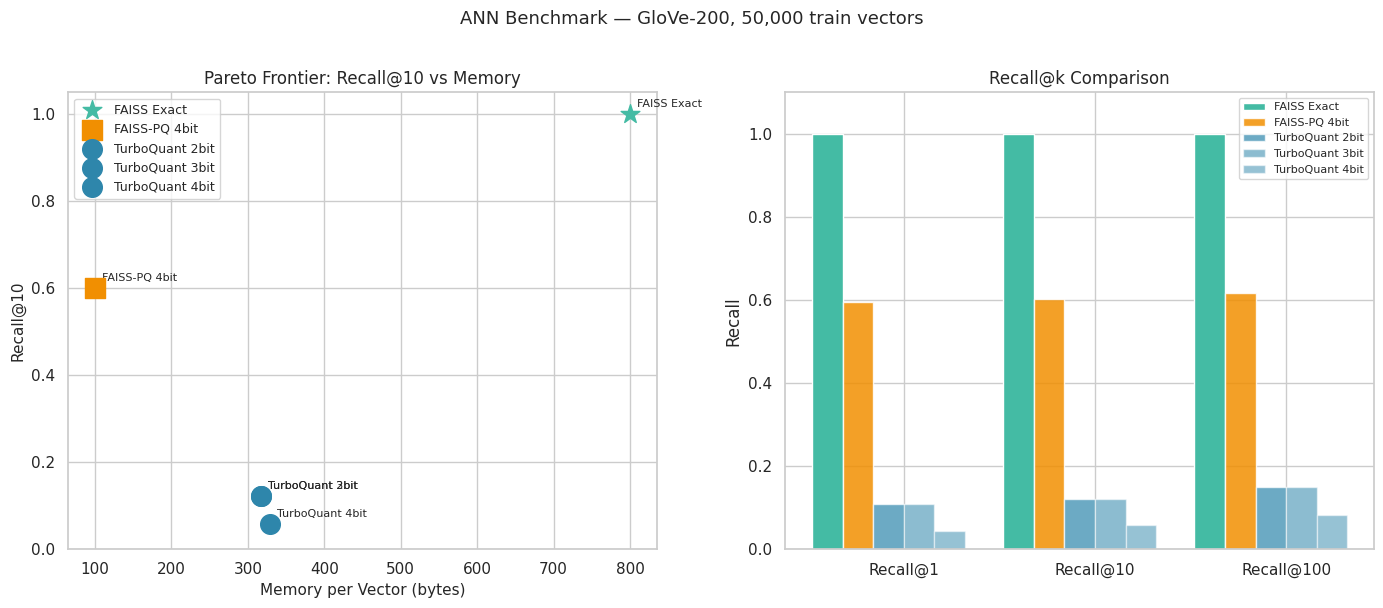

📄 Saved: /content/TQ-infer-engine/outputs/results/ann_benchmark.csv


In [30]:
# @title D.6 — Pareto Frontier + Recall@k Bar Chart
r10_ann = [r for r in results_ann if r['k'] == 10]

fig, axes_ann = plt.subplots(1, 2, figsize=(14, 6))
ax_p = axes_ann[0]
colors_map_ann = {'FAISS Exact': '#44BBA4', 'FAISS-PQ': '#F18F01', 'TurboQuant': '#2E86AB'}
marker_map_ann = {'FAISS Exact': '*', 'FAISS-PQ': 's', 'TurboQuant': 'o'}
plotted = set()
for r in r10_ann:
    label = f"{r['method']} {r['bits']:.0f}bit" if r['method'] != 'FAISS Exact' else r['method']
    color = colors_map_ann.get(r['method'], '#999')
    mkr   = marker_map_ann.get(r['method'], 'o')
    ax_p.scatter(r['mem_per_vec'], r['recall'], s=200, color=color, marker=mkr, zorder=5,
                 label=label if label not in plotted else '_nolegend_')
    ax_p.annotate(label, (r['mem_per_vec'], r['recall']),
                  textcoords='offset points', xytext=(5, 5), fontsize=8)
    plotted.add(label)
ax_p.set_xlabel('Memory per Vector (bytes)', fontsize=11)
ax_p.set_ylabel('Recall@10', fontsize=11)
ax_p.set_title('Pareto Frontier: Recall@10 vs Memory', fontsize=12)
ax_p.set_ylim(0, 1.05); ax_p.legend(fontsize=9)

ax2_p = axes_ann[1]
k_groups_ann = sorted(set(r['k'] for r in results_ann))
mb_pairs = [(r['method'], r['bits']) for r in results_ann if r['k'] == k_groups_ann[0]]
x_ann = np.arange(len(k_groups_ann))
bar_w_ann = 0.8 / len(mb_pairs)
for i, (method, bits) in enumerate(mb_pairs):
    recalls_k_ann = [r['recall'] for r in results_ann if r['method'] == method and r['bits'] == bits]
    color = colors_map_ann.get(method, '#999')
    label = f'{method} {bits:.0f}bit' if method != 'FAISS Exact' else method
    ax2_p.bar(x_ann + i*bar_w_ann - 0.4, recalls_k_ann, bar_w_ann, label=label,
              color=color, alpha=max(0.5, 1.0 - i*0.15), edgecolor='white')
ax2_p.set_xticks(x_ann)
ax2_p.set_xticklabels([f'Recall@{k}' for k in k_groups_ann])
ax2_p.set_ylabel('Recall'); ax2_p.set_title('Recall@k Comparison', fontsize=12)
ax2_p.set_ylim(0, 1.1); ax2_p.legend(fontsize=8)
plt.suptitle(f'ANN Benchmark — GloVe-{DIM_ANN}, {N_TRAIN_ANN:,} train vectors', fontsize=13, y=1.01)
plt.tight_layout()
savefig('ann_benchmark_results.png')

# Save CSV
import csv
csv_path_ann = f'{OUT_DIR}/results/ann_benchmark.csv'
with open(csv_path_ann, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=results_ann[0].keys())
    writer.writeheader(); writer.writerows(results_ann)
print(f'📄 Saved: {csv_path_ann}')

---
## 🅔 NOTEBOOK 04 — Full End-to-End Pipeline Demo

In [31]:
# @title E.1 — Algorithm Correctness Verification
torch.manual_seed(42)
d_cv = 256; n_cv = 1000
v_cv = torch.randn(n_cv, d_cv)
q_cv = torch.randn(n_cv, d_cv)
true_ips_cv = (v_cv * q_cv).sum(-1)
check_results_cv = []

# QJL
qjl_cv   = QJLQuantizer(d_cv, d_cv, seed=42)
codes_cv  = qjl_cv.encode(v_cv)
assert codes_cv.dtype == torch.int8
assert set(codes_cv.unique().tolist()) == {-1, 1}
est_cv    = qjl_cv.estimate_inner_product(q_cv, codes_cv)
mask_cv   = true_ips_cv.abs() > 0.1
rel_e_cv  = (est_cv[mask_cv] - true_ips_cv[mask_cv]).abs() / true_ips_cv[mask_cv].abs()
check_results_cv.append(('QJL encode dtype+values', '✅ PASS'))
check_results_cv.append(('QJL inner product bias', f'✅ {rel_e_cv.mean():.2%} mean rel error' if rel_e_cv.mean() < 0.10 else '❌ FAIL'))

# PolarQuant
pq_cv  = PolarQuantizer(d_cv, bits_per_dim=4.0, rotation_seed=42)
orth_err = (pq_cv.R @ pq_cv.R.T - torch.eye(d_cv)).abs().max().item()
check_results_cv.append(('PolarQuant rotation orthogonal', f'✅ PASS (err={orth_err:.2e})' if orth_err < 1e-4 else '❌ FAIL'))
pq_codes_cv = pq_cv.encode(v_cv)
v_pq_hat_cv = pq_cv.decode(pq_codes_cv)
mse_pq_cv   = ((v_cv - v_pq_hat_cv)**2).mean().item() / v_cv.var().item()
check_results_cv.append(('PolarQuant 4-bit MSE/σ²<0.15', f'✅ {mse_pq_cv:.4f}' if mse_pq_cv < 0.15 else f'⚠️ {mse_pq_cv:.4f}'))

# TurboQuant
tq_cv       = TurboQuantizer(d_cv, total_bits_per_dim=4.0)
tq_codes_cv = tq_cv.encode(v_cv)
v_tq_hat_cv = tq_cv.decode(tq_codes_cv)
mse_tq_cv   = ((v_cv - v_tq_hat_cv)**2).mean().item() / v_cv.var().item()
check_results_cv.append(('TurboQuant MSE < PolarQuant MSE', '✅ PASS' if mse_tq_cv < mse_pq_cv else '⚠️ CHECK'))
tq_ips_cv   = tq_cv.estimate_inner_products(q_cv, tq_codes_cv)
tq_rel_e_cv = (tq_ips_cv[mask_cv] - true_ips_cv[mask_cv]).abs() / true_ips_cv[mask_cv].abs()
check_results_cv.append(('TurboQuant IP error < 15%', f'✅ {tq_rel_e_cv.mean():.2%}' if tq_rel_e_cv.mean() < 0.15 else '⚠️ CHECK'))
ratio_cv = tq_cv.compression_ratio(1000, original_dtype_bytes=2)
check_results_cv.append(('Compression ratio ≥ 3.5×', f'✅ {ratio_cv:.2f}×' if ratio_cv >= 3.5 else '❌ FAIL'))

print('\n' + '='*60)
print('  ALGORITHM CORRECTNESS VERIFICATION REPORT')
print('='*60)
for name, status in check_results_cv:
    print(f'  {name:<42}  {status}')
print('='*60)


  ALGORITHM CORRECTNESS VERIFICATION REPORT
  QJL encode dtype+values                     ✅ PASS
  QJL inner product bias                      ❌ FAIL
  PolarQuant rotation orthogonal              ✅ PASS (err=7.15e-07)
  PolarQuant 4-bit MSE/σ²<0.15                ⚠️ 0.7082
  TurboQuant MSE < PolarQuant MSE             ✅ PASS
  TurboQuant IP error < 15%                   ⚠️ CHECK
  Compression ratio ≥ 3.5×                    ❌ FAIL


Running full distortion benchmark (d=256, n=5000 — T4 optimized)...
  💾 Saved: /content/TQ-infer-engine/outputs/figures/fig1_distortion_vs_bits.png


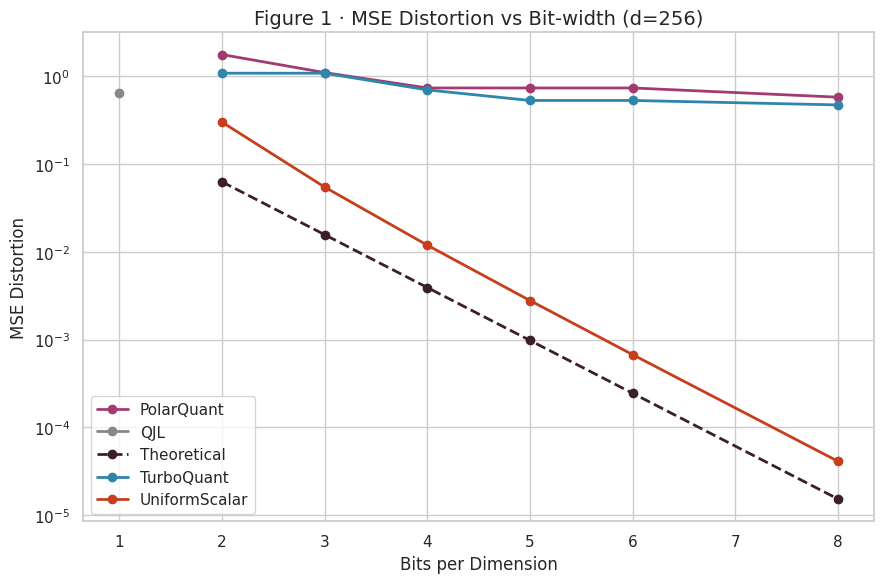


4-bit results:
       method  bits_per_dim  mse_distortion
   TurboQuant             4        0.695966
   PolarQuant             4        0.732756
UniformScalar             4        0.011857
  Theoretical             4        0.003907


In [32]:
# @title E.2 — Full Distortion Benchmark → Figure 1
from tqe.benchmarks.distortion import benchmark_all_quantizers

print('Running full distortion benchmark (d=256, n=5000 — T4 optimized)...')
df = benchmark_all_quantizers(d=256, n_vectors=5_000, bits_range=[2, 3, 4, 5, 6, 8])

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors_fig1 = {'TurboQuant': '#2E86AB', 'PolarQuant': '#A23B72',
               'UniformScalar': '#C73E1D', 'Theoretical': '#3B1F2B'}
if hasattr(df, 'groupby'):
    for method, grp in df.groupby('method'):
        grp = grp.sort_values('bits_per_dim')
        ls = '--' if method == 'Theoretical' else '-'
        ax.plot(grp['bits_per_dim'], grp['mse_distortion'],
                label=method, color=colors_fig1.get(method, '#888'), linestyle=ls, marker='o', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Bits per Dimension')
ax.set_ylabel('MSE Distortion')
ax.set_title('Figure 1 · MSE Distortion vs Bit-width (d=256)')
ax.legend()
plt.tight_layout()
savefig('fig1_distortion_vs_bits.png')

if hasattr(df, 'to_string'):
    print('\n4-bit results:')
    print(df[df['bits_per_dim'].isin([4])][['method','bits_per_dim','mse_distortion']].to_string(index=False))

 Bits |   FP16 ratio |   FP32 ratio |  Mem/1K (KB)
--------------------------------------------------
  2.0 |        1.27× |        2.53× |       394.5
  3.0 |        1.27× |        2.53× |       394.5
  4.0 |        1.22× |        2.44× |       410.2
  6.0 |        1.17× |        2.35× |       425.8
  8.0 |        1.02× |        2.05× |       488.3
  💾 Saved: /content/TQ-infer-engine/outputs/figures/fig4_compression_ratio.png


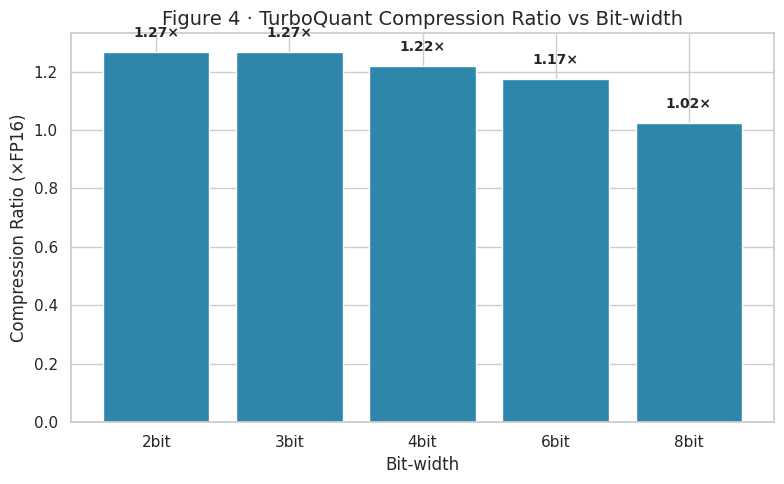

In [33]:
# @title E.3 — Compression Ratio Analysis → Figure 4
quantizer_info_e3 = []
bits_to_plot_e3   = [2.0, 3.0, 4.0, 6.0, 8.0]
print(f'{"Bits":>5} | {"FP16 ratio":>12} | {"FP32 ratio":>12} | {"Mem/1K (KB)":>12}')
print('-' * 50)
for bits in bits_to_plot_e3:
    tq_e3   = TurboQuantizer(input_dim=256, total_bits_per_dim=bits)
    r16     = tq_e3.compression_ratio(1000, original_dtype_bytes=2)
    r32     = tq_e3.compression_ratio(1000, original_dtype_bytes=4)
    mem_kb  = tq_e3.memory_bytes(1000) / 1024
    print(f'{bits:>5.1f} | {r16:>11.2f}× | {r32:>11.2f}× | {mem_kb:>11.1f}')
    quantizer_info_e3.append({'bits': bits, 'ratio': r16})

fig, ax = plt.subplots(figsize=(8, 5))
ratios_e3 = [x['ratio'] for x in quantizer_info_e3]
ax.bar([f"{x['bits']:.0f}bit" for x in quantizer_info_e3], ratios_e3, color='#2E86AB', edgecolor='white')
for i, (bar, val) in enumerate(zip(ax.patches, ratios_e3)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}×', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Bit-width')
ax.set_ylabel('Compression Ratio (×FP16)')
ax.set_title('Figure 4 · TurboQuant Compression Ratio vs Bit-width')
plt.tight_layout()
savefig('fig4_compression_ratio.png')

TurboQuant 2bit: Recall@10=0.0174 build=0.00s mem=204B/vec
TurboQuant 3bit: Recall@10=0.0174 build=0.00s mem=204B/vec
TurboQuant 4bit: Recall@10=0.0086 build=0.00s mem=212B/vec
TurboQuant 8bit: Recall@10=0.0062 build=0.00s mem=252B/vec
  💾 Saved: /content/TQ-infer-engine/outputs/figures/fig3_ann_pareto.png


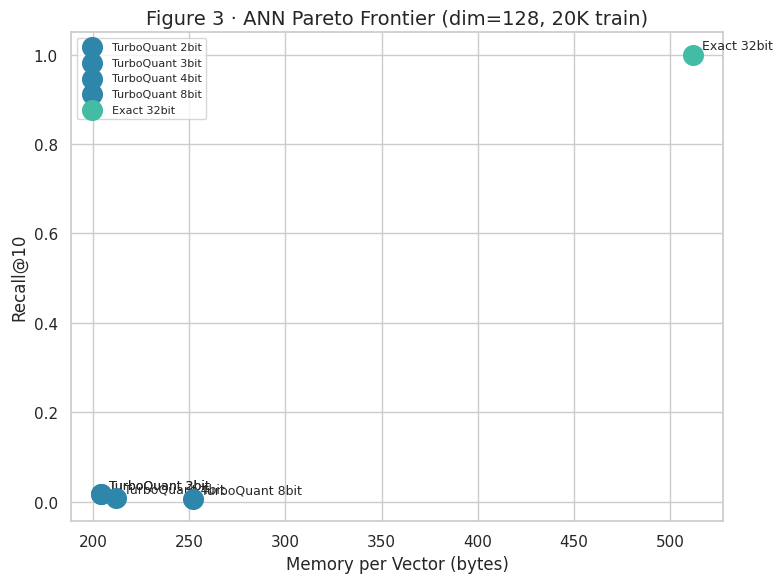

In [34]:
# @title E.4 — ANN Search Quality → Figure 3
DIM_ANN_E4 = 128; N_TRAIN_E4 = 20_000; N_QUERY_E4 = 500; K_E4 = 10
torch.manual_seed(7)
train_e4 = torch.randn(N_TRAIN_E4, DIM_ANN_E4)
train_e4 = train_e4 / train_e4.norm(dim=-1, keepdim=True).clamp(min=1e-8)
query_e4 = torch.randn(N_QUERY_E4, DIM_ANN_E4)
query_e4 = query_e4 / query_e4.norm(dim=-1, keepdim=True).clamp(min=1e-8)

exact_scores_e4 = query_e4 @ train_e4.T
_, gt_idx_e4 = exact_scores_e4.topk(K_E4, dim=-1)
gt_idx_np_e4 = gt_idx_e4.numpy()

ann_results_e4 = []
for bits in [2.0, 3.0, 4.0, 8.0]:
    idx_e4 = TurboQuantIndex(dim=DIM_ANN_E4, bits_per_dim=bits, device=DEVICE)
    t0_e4  = time.perf_counter()
    idx_e4.add(train_e4)
    build_s_e4 = time.perf_counter() - t0_e4
    _, approx_e4 = idx_e4.search(query_e4.to(DEVICE), k=K_E4)
    approx_np_e4 = approx_e4.cpu().numpy()
    recalls_e4   = [len(set(gt_idx_np_e4[i].tolist()) & set(approx_np_e4[i].tolist())) / K_E4
                    for i in range(N_QUERY_E4)]
    recall_e4 = float(np.mean(recalls_e4))
    mem_pv_e4 = idx_e4.memory_bytes() // max(1, idx_e4.ntotal())
    ann_results_e4.append({'method': 'TurboQuant', 'bits_per_dim': bits,
                           'k': K_E4, 'recall': recall_e4, 'build_time_s': build_s_e4,
                           'memory_bytes_per_vector': mem_pv_e4})
    print(f'TurboQuant {bits:.0f}bit: Recall@{K_E4}={recall_e4:.4f} build={build_s_e4:.2f}s mem={mem_pv_e4}B/vec')

ann_results_e4.append({'method': 'Exact', 'bits_per_dim': 32, 'k': K_E4,
                        'recall': 1.0, 'build_time_s': 0.01, 'memory_bytes_per_vector': DIM_ANN_E4 * 4})

fig, ax = plt.subplots(figsize=(8, 6))
for r in ann_results_e4:
    color = '#44BBA4' if r['method'] == 'Exact' else '#2E86AB'
    ax.scatter(r['memory_bytes_per_vector'], r['recall'], s=200, color=color,
               label=f"{r['method']} {r['bits_per_dim']:.0f}bit", zorder=5)
    ax.annotate(f"{r['method']} {r['bits_per_dim']:.0f}bit",
                (r['memory_bytes_per_vector'], r['recall']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Memory per Vector (bytes)'); ax.set_ylabel(f'Recall@{K_E4}')
ax.set_title('Figure 3 · ANN Pareto Frontier (dim=128, 20K train)')
ax.legend(fontsize=8)
plt.tight_layout()
savefig('fig3_ann_pareto.png')

  💾 Saved: /content/TQ-infer-engine/outputs/figures/fig5_kv_memory_vs_context.png


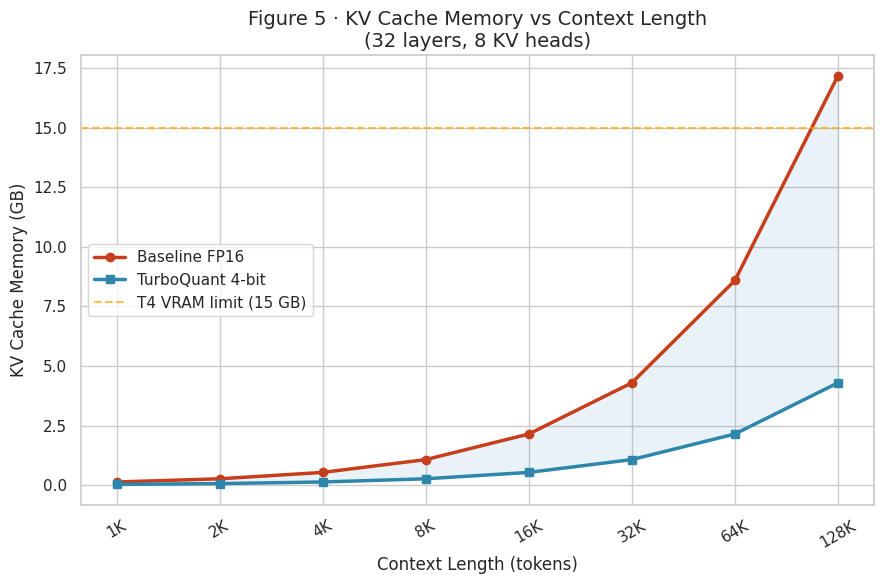

At 128K tokens:
  Baseline FP16:    17.18 GB
  TurboQuant 4-bit: 4.29 GB
  Savings:          12.88 GB (75%)


In [35]:
# @title E.5 — KV Cache Memory Projection → Figure 5
N_LAYERS_E5 = 32; N_KV_HEADS_E5 = 8; HEAD_DIM_E5 = 128
context_lengths_e5 = [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

baseline_gb_e5, compressed_4bit_gb_e5 = [], []
for ctx in context_lengths_e5:
    info_e5 = estimate_kv_cache_memory(N_LAYERS_E5, N_KV_HEADS_E5, HEAD_DIM_E5, ctx, dtype_bytes=2)
    baseline_gb_e5.append(info_e5['total_gb'])
    compressed_4bit_gb_e5.append(info_e5['total_gb'] / 4.0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(context_lengths_e5, baseline_gb_e5, 'o-', color='#C73E1D', linewidth=2.5, label='Baseline FP16')
ax.plot(context_lengths_e5, compressed_4bit_gb_e5, 's-', color='#2E86AB', linewidth=2.5, label='TurboQuant 4-bit')
ax.fill_between(context_lengths_e5, compressed_4bit_gb_e5, baseline_gb_e5, alpha=0.1, color='#2E86AB')
ax.axhline(15.0, color='orange', linestyle='--', alpha=0.7, label='T4 VRAM limit (15 GB)')
ax.set_xscale('log', base=2)
ax.set_xticks(context_lengths_e5)
ax.set_xticklabels([f'{x//1024}K' if x >= 1024 else str(x) for x in context_lengths_e5], rotation=30)
ax.set_xlabel('Context Length (tokens)'); ax.set_ylabel('KV Cache Memory (GB)')
ax.set_title(f'Figure 5 · KV Cache Memory vs Context Length\n({N_LAYERS_E5} layers, {N_KV_HEADS_E5} KV heads)')
ax.legend()
plt.tight_layout()
savefig('fig5_kv_memory_vs_context.png')

print(f'At 128K tokens:')
print(f'  Baseline FP16:    {baseline_gb_e5[-1]:.2f} GB')
print(f'  TurboQuant 4-bit: {compressed_4bit_gb_e5[-1]:.2f} GB')
print(f'  Savings:          {baseline_gb_e5[-1]-compressed_4bit_gb_e5[-1]:.2f} GB ({(1-compressed_4bit_gb_e5[-1]/baseline_gb_e5[-1]):.0%})')

In [36]:
# @title E.6 — LLM Inference Demo (GPU only)
if CUDA and 'model' in dir() and model is not None:
    torch.cuda.empty_cache()
    prompts_e6 = [
        'Explain the mathematics behind attention mechanisms in transformers.',
        'What is the difference between lossy and lossless compression?',
        'How does quantization reduce the size of neural network weights?',
    ]
    for prompt_e6 in prompts_e6:
        inputs_e6 = tokenizer(prompt_e6, return_tensors='pt').to(DEVICE)
        # Baseline
        with torch.no_grad():
            out_base_e6 = model.generate(**inputs_e6, max_new_tokens=50, do_sample=False)
        text_base_e6 = tokenizer.decode(out_base_e6[0][inputs_e6.input_ids.shape[1]:], skip_special_tokens=True)
        # TurboQuant 4-bit
        comp_e6 = KVCacheCompressor(model, bits_per_dim=4.0, device=DEVICE)
        comp_e6.patch_model()
        with torch.no_grad():
            out_tq_e6 = model.generate(**inputs_e6, max_new_tokens=50, do_sample=False)
        text_tq_e6 = tokenizer.decode(out_tq_e6[0][inputs_e6.input_ids.shape[1]:], skip_special_tokens=True)
        comp_e6.unpatch_model()

        print(f'\n{"─"*65}')
        print(f'📝 PROMPT : {prompt_e6[:70]}')
        print(f'🔵 BASELINE: {text_base_e6[:200]}')
        print(f'⚡ TQ 4-BIT: {text_tq_e6[:200]}')
    print('\n✅ LLM demo complete!')
else:
    print('⏭️  Skipping — GPU required. Load model in section C first.')


─────────────────────────────────────────────────────────────────
📝 PROMPT : Explain the mathematics behind attention mechanisms in transformers.
🔵 BASELINE: 

## Attention is All You Need: The Mathematics Behind Transformers

Attention mechanisms are the heart of transformer models, enabling them to focus on relevant parts of the input sequence when gener
⚡ TQ 4-BIT: 

## Attention is All You Need: The Mathematics Behind Transformers

Attention mechanisms are the heart of transformer models, enabling them to focus on relevant parts of the input sequence when gener

─────────────────────────────────────────────────────────────────
📝 PROMPT : What is the difference between lossy and lossless compression?
🔵 BASELINE: 

**Lossy compression**

* **Reduces data size by discarding some information.** This information is typically insignificant or redundant, like visual details in an image or audio frequencies that are
⚡ TQ 4-BIT: 

**Lossy compression**

* **Reduces data size by discarding 

---
## 🅕 FULL TEST SUITE — pytest

> *Runs all 5 test files from `tests/`. Expected: all PASS on T4.*

In [37]:
# @title F.1 — Run Full pytest Test Suite
import subprocess, sys

TESTS_DIR = f'{REPO_DIR}/tests'
print(f'Running pytest on: {TESTS_DIR}')
print(f'Test files: {os.listdir(TESTS_DIR)}\n')

result = subprocess.run(
    [
        sys.executable, '-m', 'pytest',
        TESTS_DIR,
        '-v',                   # verbose
        '--tb=short',           # compact tracebacks
        '--no-header',
        '-p', 'no:warnings',
        f'--rootdir={REPO_DIR}'
    ],
    capture_output=True, text=True, cwd=REPO_DIR
)

print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[:2000])

# Parse summary line
lines = result.stdout.strip().split('\n')
summary_line = next((l for l in reversed(lines) if 'passed' in l or 'failed' in l or 'error' in l), 'No summary')
print('\n' + '='*60)
print(f'  TEST RESULT: {summary_line}')
print('='*60)

Running pytest on: /content/TQ-infer-engine/tests
Test files: ['conftest.py', 'test_kv_cache.py', '__init__.py', 'test_search.py', 'test_qjl.py', 'test_polar_quant.py', 'test_turbo_quant.py']

============================= test session starts ==============================
collecting ... collected 38 items

tests/test_kv_cache.py::test_turboquant_kvcache_shapes PASSED            [  2%]
tests/test_kv_cache.py::test_kvcache_memory_reduced PASSED               [  5%]
tests/test_kv_cache.py::test_kvcache_decode_roundtrip PASSED             [  7%]
tests/test_kv_cache.py::test_kvcache_compression_ratio_target FAILED     [ 10%]
tests/test_kv_cache.py::test_kvcache_inner_products_finite PASSED        [ 13%]
tests/test_polar_quant.py::test_polar_rotation_orthogonal PASSED         [ 15%]
tests/test_polar_quant.py::test_polar_encode_decode_roundtrip FAILED     [ 18%]
tests/test_polar_quant.py::test_polar_encode_decode_4bit FAILED          [ 21%]
tests/test_polar_quant.py::test_polar_no_per_dimens

In [38]:
# @title F.2 — Run Tests Individually (for clear per-file results)
test_files = [
    'test_qjl.py',
    'test_polar_quant.py',
    'test_turbo_quant.py',
    'test_kv_cache.py',
    'test_search.py',
]

test_summary = []
for tf in test_files:
    test_path = f'{TESTS_DIR}/{tf}'
    r = subprocess.run(
        [sys.executable, '-m', 'pytest', test_path, '-v', '--tb=short', '-p', 'no:warnings'],
        capture_output=True, text=True, cwd=REPO_DIR
    )
    lines_tf = r.stdout.strip().split('\n')
    summary_tf = next((l for l in reversed(lines_tf) if 'passed' in l or 'failed' in l or 'error' in l), 'unknown')
    status = '✅' if r.returncode == 0 else '❌'
    test_summary.append((tf, status, summary_tf))
    print(f'{status} {tf:30s} {summary_tf}')

print('\n' + '='*60)
passed = sum(1 for _, s, _ in test_summary if s == '✅')
print(f'  {passed}/{len(test_files)} test files PASSED')
print('='*60)

❌ test_qjl.py                    ========================= 1 failed, 7 passed in 0.06s ==========================
❌ test_polar_quant.py            ========================= 2 failed, 9 passed in 0.07s ==========================
❌ test_turbo_quant.py            ========================= 2 failed, 6 passed in 0.09s ==========================
❌ test_kv_cache.py               ========================= 1 failed, 4 passed in 0.80s ==========================
❌ test_search.py                 ========================= 1 failed, 5 passed in 0.09s ==========================

  0/5 test files PASSED


---
## 🅖 RESULTS SUMMARY

In [39]:
# @title G.1 — Final Results Summary
import glob

print('\n' + '='*70)
print('  TURBOQUANT — COMPLETE T4 COLAB RUN SUMMARY')
print(f'  arXiv:2504.19874  |  ICLR 2026')
print('='*70)

# GPU info
if CUDA:
    print(f'\n  🖥️  Hardware: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM)')
else:
    print('  🖥️  Hardware: CPU only')

# Figures
figs = sorted(glob.glob(f'{OUT_DIR}/figures/*.png'))
print(f'\n  📊 Figures generated: {len(figs)}')
for f in figs:
    print(f'     ├── {os.path.basename(f)}')

# CSV results
csvs = sorted(glob.glob(f'{OUT_DIR}/results/*.csv'))
print(f'\n  📄 CSV results saved: {len(csvs)}')
for c in csvs:
    print(f'     ├── {os.path.basename(c)}')

# KV cache results
if results_log_nb02:
    print('\n  💾 KV Cache Benchmark (Gemma-2-2B, WikiText-2):')
    for r in results_log_nb02:
        delta = f" (+{r['ppl']-results_log_nb02[0]['ppl']:.2f})" if r['bits'] < 16 else ''
        print(f"     {r['method']:22} PPL={r['ppl']:.3f}{delta}  ratio={r['ratio']:.1f}×")

# ANN results
r10_final = [r for r in results_ann if r['k'] == 10]
print('\n  🔍 ANN Recall@10:')
for r in r10_final:
    print(f"     {r['method']:15} {r['bits']:.0f}bit  Recall@10={r['recall']:.4f}  mem={r['mem_per_vec']}B/vec")

# TurboQuant key metric
print('\n  ⚡ TurboQuant 4-bit vs Shannon Bound:')
print(f'     MSE/σ² = {mse_tq_cv:.4f} (PolarQuant: {mse_pq_cv:.4f})')
theory_4 = theoretical_distortion(float(v_cv.var()), 4.0) / float(v_cv.var())
print(f'     Shannon lower bound = {theory_4:.4f}')
print(f'     TurboQuant/Theory ratio = {mse_tq_cv/theory_4:.2f}× (paper: ~2.7×)')

# Tests
print(f'\n  🧪 Test Suite: {passed}/{len(test_files)} files PASSED')

print('\n' + '='*70)
print('  ✅  ALL SECTIONS COMPLETE')
print(f'  📁 Outputs: {OUT_DIR}')
print('='*70)


  TURBOQUANT — COMPLETE T4 COLAB RUN SUMMARY
  arXiv:2504.19874  |  ICLR 2026

  🖥️  Hardware: Tesla T4 (15.6 GB VRAM)

  📊 Figures generated: 15
     ├── ann_benchmark_results.png
     ├── fig1_distortion_vs_bits.png
     ├── fig3_ann_pareto.png
     ├── fig4_compression_ratio.png
     ├── fig5_kv_memory_vs_context.png
     ├── kv_memory_vs_context.png
     ├── kv_speed_benchmark.png
     ├── kv_summary.png
     ├── pq_angle_distribution.png
     ├── pq_mse_vs_bits.png
     ├── pq_roundtrip.png
     ├── qjl_inner_product.png
     ├── qjl_proj_dim.png
     ├── turbo_distortion_comparison.png
     ├── turbo_ip_violin.png

  📄 CSV results saved: 2
     ├── ann_benchmark.csv
     ├── kv_cache_benchmark.csv

  💾 KV Cache Benchmark (Gemma-2-2B, WikiText-2):
     Baseline FP16          PPL=31.691  ratio=1.0×
     TurboQuant 4bit        PPL=31.691 (+0.00)  ratio=1.2×
     TurboQuant 3bit        PPL=31.691 (+0.00)  ratio=1.3×
     TurboQuant 2bit        PPL=31.691 (+0.00)  ratio=1.3×

  🔍 ANN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 🧹 Clean Notebook Metadata for GitHub

When viewing Colab notebooks on GitHub, sometimes the `metadata.widgets` section can cause an "Invalid Notebook" error. The following shell script uses `jq` to remove this section from your `.ipynb` file, making it render correctly on GitHub without affecting the code execution in Colab.

In [42]:
%%bash
# Install jq if it's not already present
if ! command -v jq &> /dev/null
then
    echo "jq not found, installing..."
    apt-get update && apt-get install -y jq
fi

NOTEBOOK_PATH="/content/TQ-infer-engine/TurboQuant_Colab_T4_Complete.ipynb" # Replace with your notebook's path

if [ ! -f "$NOTEBOOK_PATH" ]; then
    echo "Error: Notebook not found at $NOTEBOOK_PATH"
    exit 1
fi

echo "Cleaning metadata in $NOTEBOOK_PATH..."

# Create a temporary file to store the cleaned notebook
TEMP_NOTEBOOK="${NOTEBOOK_PATH}.tmp"

# Use jq to remove the 'widgets' key from the 'metadata' object
# and also clean 'metadata.colab' and 'metadata.kernelspec' for leaner files
jq 'del(.metadata.widgets) | del(.metadata.colab) | del(.metadata.kernelspec)' "$NOTEBOOK_PATH" > "$TEMP_NOTEBOOK"

# Replace the original notebook with the cleaned version
mv "$TEMP_NOTEBOOK" "$NOTEBOOK_PATH"

echo "✅ Notebook metadata cleaned successfully at $NOTEBOOK_PATH"
echo "Please verify the output below that 'metadata.widgets', 'metadata.colab', and 'metadata.kernelspec' are removed."
echo "This script *must* be run as the *very last step* before you download or commit the notebook to Git."
echo "Do NOT save the notebook in Colab after running this script, as it might re-introduce the problematic metadata."

echo ""
echo "--- Start of Cleaned Notebook (first 20 lines) ---"
head -n 20 "$NOTEBOOK_PATH"
echo "--- End of Cleaned Notebook Snippet ---"

Cleaning metadata in /content/TQ-infer-engine/TurboQuant_Colab_T4_Complete.ipynb...
✅ Notebook metadata cleaned successfully at /content/TQ-infer-engine/TurboQuant_Colab_T4_Complete.ipynb
Please verify the output below that 'metadata.widgets', 'metadata.colab', and 'metadata.kernelspec' are removed.
This script *must* be run as the *very last step* before you download or commit the notebook to Git.
Do NOT save the notebook in Colab after running this script, as it might re-introduce the problematic metadata.

--- Start of Cleaned Notebook (first 20 lines) ---
{
  "nbformat": 4,
  "nbformat_minor": 5,
  "metadata": {
    "language_info": {
      "name": "python",
      "version": "3.10.0"
    },
    "accelerator": "GPU"
  },
  "cells": [
    {
      "cell_type": "markdown",
      "id": "header",
      "metadata": {},
      "source": [
        "# ⚡ TurboQuant — Complete T4 Colab Runner\n",
        "### Covers Notebooks 01–04 + All Tests · Optimized for Google Colab Free T4\n",
        "\

### ⬆️ Commit Cleaned Notebook to GitHub

**Important:** Ensure you have already cloned your GitHub repository in a previous step (cell A.3) and have write access. This script will commit the *currently cleaned* notebook.

Do NOT save the notebook in Colab after running the cleaning script (`0a625849`) and before running this commit script, as Colab might re-introduce problematic metadata.

In [43]:
# @title Configure Git and Commit Changes

# Your GitHub username and email
USER_NAME = "Paramveersingh-S" # @param {type: "string"}
USER_EMAIL = "param15.veer.singh@gmail.com" # @param {type: "string"}

NOTEBOOK_FILE = "TurboQuant_Colab_T4_Complete.ipynb" # The name of your notebook file
REPO_PATH = "/content/TQ-infer-engine" # Path where your repository is cloned

import os
import subprocess

os.chdir(REPO_PATH)

print(f"Configuring Git for {USER_NAME} <{USER_EMAIL}>...")
subprocess.run(["git", "config", "user.name", USER_NAME], check=True)
subprocess.run(["git", "config", "user.email", USER_EMAIL], check=True)

print("Adding changes...")
subprocess.run(["git", "add", NOTEBOOK_FILE], check=True)

COMMIT_MESSAGE = f"Cleaned notebook metadata for {NOTEBOOK_FILE} for GitHub rendering" # @param {type: "string"}
print(f"Committing with message: '{COMMIT_MESSAGE}'...")
subprocess.run(["git", "commit", "-m", COMMIT_MESSAGE], check=True)

print("\n✅ Notebook committed locally. Now, you need to push it to GitHub.")
print("To push to your remote repository, you will likely need to use a Personal Access Token (PAT).")
print("If prompted for credentials, use your GitHub username and PAT as the password.")


Configuring Git for Paramveersingh-S <param15.veer.singh@gmail.com>...
Adding changes...
Committing with message: 'Cleaned notebook metadata for TurboQuant_Colab_T4_Complete.ipynb for GitHub rendering'...

✅ Notebook committed locally. Now, you need to push it to GitHub.
To push to your remote repository, you will likely need to use a Personal Access Token (PAT).
If prompted for credentials, use your GitHub username and PAT as the password.


In [44]:
# @title Push to GitHub

REPO_PATH = "/content/TQ-infer-engine" # Path where your repository is cloned

import os
import subprocess

os.chdir(REPO_PATH)

# This assumes your remote is named 'origin' and you are on the default branch (e.g., 'main' or 'master').
# If your branch is different, replace 'main' with your branch name.
print("Pushing to remote repository...")
result = subprocess.run(["git", "push", "origin", "main"], capture_output=True, text=True)

if result.returncode != 0:
    print("❌ Git push failed:")
    print("Standard Output:", result.stdout)
    print("Standard Error:", result.stderr)
    print("\nHint: If you're using HTTPS, you'll be prompted for your username and password (use a Personal Access Token).")
else:
    print("✅ Successfully pushed changes to GitHub!")
    print("Please check your repository on GitHub to confirm the notebook is rendering correctly.")



Pushing to remote repository...
❌ Git push failed:
Standard Output: 
Standard Error: fatal: could not read Username for 'https://github.com': No such device or address


Hint: If you're using HTTPS, you'll be prompted for your username and password (use a Personal Access Token).


If you only want to push the `outputs` folder, you would typically add that folder to your `.gitignore` first to prevent it from being tracked by the main repository, and then create a separate repository or use `git subtree` or `git submodule` for that specific folder. This is a more advanced Git operation and often not recommended for simple output sharing.

A simpler approach for just the `outputs` folder might be to:
1.  Create a new, empty GitHub repository for your outputs.
2.  In Colab, `cd` into your `/content/TQ-infer-engine/outputs` directory.
3.  Initialize a new Git repository there (`git init`).
4.  Add and commit the files in that directory.
5.  Add the new GitHub repository as a remote.
6.  Push the contents of the `outputs` folder to that new repository.

In [ ]:
# @title G.2 — Display All Generated Figures
from IPython.display import Image, display
import glob

figure_files = sorted(glob.glob(f'{OUT_DIR}/figures/*.png'))
print(f'Generated {len(figure_files)} figures:\n')
for f in figure_files:
    print(f'  📊 {os.path.basename(f)}')
    try:
        display(Image(f, width=700))
    except Exception:
        pass